# **Implementación de modelos**

## **Librerías y módulos necesarios**

In [2]:
import os
import time
import json
import pickle
import random
import fasttext
import traceback
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import tensorflow as tf
import matplotlib.pyplot as plt

from itertools import product
from collections import Counter
from sklearn.utils import class_weight
from gensim.models import KeyedVectors
from imblearn.over_sampling import SMOTE
from IPython.display import display, HTML
from xgboost.callback import TrainingCallback
from sklearn.preprocessing import label_binarize
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, GlobalMaxPooling1D, concatenate
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_auc_score,
    auc,
    roc_curve
)

In [2]:
import nltk
for pkg in [
    'wordnet',
    'omw-1.4',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng'
]:
    try:
        nltk.data.find(f'taggers/{pkg}')
    except LookupError:
        nltk.download(pkg)


[nltk_data] Downloading package wordnet to /home/valcd/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/valcd/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
sns.set_style('darkgrid')
plt.rcParams['font.size'] = 18
plt.rcParams['figure.figsize'] = (12, 9)

## **Cargue y preparación de datos**

En primer lugar, se hizo el cargue de la base de datos resultante y se separó en los cojuntos de entrenamiento, validación y prueba.

In [3]:
data = pd.read_csv('../data/dataprocesada.csv')

In [5]:
X = data['Resume_str_clean']
y = data['Category_code']

In [6]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, 
    y, 
    test_size=0.15, 
    random_state=21,
    stratify=y 
)

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, 
    y_trainval, 
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15 del total
    random_state=21, 
    stratify=y_trainval
)

Debido al desbalance encontrado en el conjunto de entrenamiento, se aplicó un proceso de aumentación de datos únicamente a aquellas clases cuya cantidad de observaciones estaba por debajo del 80% del promedio de observaciones por clase.

A partir de este resultado, se creó un nuevo archivo de tipo CSV que fue el que se utilizó durante el desarrollo del proyecto como el conjunto de entrenamiento.

In [8]:
df_train = pd.DataFrame({'Resume': X_train, 'Category': y_train})

num_clases = df_train['Category'].value_counts()
prom_cont = num_clases.mean()
threshold = 0.8 * prom_cont  
minoritarias = num_clases[num_clases < threshold].index.tolist()

In [9]:
target_size = int(round(prom_cont))
augmenter = naw.SynonymAug(aug_src='wordnet', aug_p=0.2)

aug_texts, aug_labels = [], []

for cls in minoritarias:
    subset = df_train[df_train['Category'] == cls]
    current_n = len(subset)
    needed_n = target_size - current_n

    if needed_n > 0:
        samples = subset.sample(needed_n, replace=True, random_state=21)
        for _, row in samples.iterrows():
            new_text = augmenter.augment(row['Resume'])
            aug_texts.append(new_text)
            aug_labels.append(cls)

In [10]:
df_aug = pd.DataFrame({'Resume': aug_texts, 'Category': aug_labels})
df_train_balanceado = pd.concat([df_train, df_aug], ignore_index=True)

In [ ]:
df_train_balanceado.to_csv('../data/train_balanceado.csv', index=False)
pd.DataFrame({'text': X_val, 'label_int': y_val}).to_csv('../data/validacion.csv', index=False)
pd.DataFrame({'text': X_test, 'label_int': y_test}).to_csv('../data/test.csv', index=False)

## **Modelos**

In [4]:
# Diccionario para guardar resultados de los modelos
if 'resultados' not in locals():
    resultados = {}

Como se mencionó anteriormente, se generó un nuevo archivo que incluye la información resultante del proceso de aumentación de datos. Además, por motivos de practicidad y consistencia, se decidió convertir también los conjuntos de validación y prueba a formato CSV, de manera que todos los modelos utilicen los mismos datos y se eviten diferencias que puedan generar sesgos en la evaluación.

In [5]:
train_df = pd.read_csv('../data/train_balanceado.csv')
val_df  = pd.read_csv('../data/validacion.csv').rename(columns={'text': 'Resume', 'label_int': 'Category'})
test_df = pd.read_csv('../data/test.csv').rename(columns={'text': 'Resume', 'label_int': 'Category'})

In [ ]:
X_train, y_train = train_df['Resume'], train_df['Category'] # Conjunto de entrenamiento
X_val,   y_val   = val_df['Resume'],   val_df['Category'] # Conjunto de validación 
X_test,  y_test  = test_df['Resume'],  test_df['Category'] # Conjunto de prueba

In [ ]:
num_clases = train_df['Category'].nunique() # Cantidad de categorías diferentes

In [ ]:
categorias = data[['Category', 'Category_code']].drop_duplicates().sort_values(by='Category_code')['Category'].tolist() # Nombre de cada categoría

### **Modelo 1: DistilBERT Fine-Tuning**

In [ ]:
import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from datasets import Dataset
from transformers import DistilBertTokenizerFast

In [9]:
MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128
OUTPUT_DIR = "./distilbert_grid_finetuned"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

train_data = Dataset.from_dict({"text": X_train, "label": y_train})
val_data   = Dataset.from_dict({"text": X_val,   "label": y_val})
test_data  = Dataset.from_dict({"text": X_test,  "label": y_test})

train_dataset = train_data.map(tokenize_function, batched=True)
val_dataset   = val_data.map(tokenize_function, batched=True)
test_dataset  = test_data.map(tokenize_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

num_labels = len(set(y_train))

Map: 100%|██████████| 373/373 [00:00<00:00, 2654.49 examples/s]


In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    return {"accuracy": acc, "precision_macro": precision, "recall_macro": recall, "f1_macro": f1}

param_grid = {
    "learning_rate": [1e-5, 2e-5, 3e-5, 5e-5],
    "batch_size": [16, 32],
    "epochs": [3, 5, 10],
    "weight_decay": [0.0, 0.01]
}

best_f1 = 0
best_params = None
best_model_dir = None

for lr, bs, n_epochs in itertools.product(param_grid["learning_rate"], param_grid["batch_size"], param_grid["epochs"]):
    print(f"\nEntrenando lr={lr} bs={bs} epochs={n_epochs}")
    model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=num_labels)
    training_args = TrainingArguments(
        output_dir=f"./tmp_lr{lr}_bs{bs}_ep{n_epochs}",
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=n_epochs,
        learning_rate=lr,
        fp16=torch.cuda.is_available(),
        logging_steps=100,
        save_total_limit=2,
        seed=21
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=None,  
        tokenizer=DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased"),
        compute_metrics=compute_metrics
    )

    trainer.train()

    metrics = trainer.predict(val_dataset)   
    val_metrics = compute_metrics(metrics)
    current_f1 = val_metrics["f1_macro"]
    print("F1_macro validación:", current_f1)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_params = {"lr": lr, "batch_size": bs, "epochs": n_epochs}
        trainer.save_model(f"./best_model_lr{lr}_bs{bs}_ep{n_epochs}")
        best_model_dir = f"./best_model_lr{lr}_bs{bs}_ep{n_epochs}"

In [12]:
display(HTML("<h4>Mejores Hiperparámetros Encontrados:</h4>"))
params_df = pd.Series(best_params, name='Valor').to_frame()
params_df.index.name = 'Hiperparámetro'
display(params_df)

,Valor
Hiperparámetro,
lr,0.00005
batch_size,32.00000
epochs,5.00000


In [ ]:
final_model_distil = DistilBertForSequenceClassification.from_pretrained(best_model_dir)
final_trainer = Trainer(
    model=final_model_distil,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

predictions = final_trainer.predict(test_dataset)

from scipy.special import softmax

y_pred_probs_distil = softmax(predictions.predictions, axis=1)
y_pred_distil = np.argmax(y_pred_probs_distil, axis=1)
y_true_distil = predictions.label_ids


accuracy_distil = accuracy_score(y_true_distil, y_pred_distil)
precision_distil = precision_score(y_true_distil, y_pred_distil, average='macro')
recall_distil = recall_score(y_true_distil, y_pred_distil, average='macro')
f1_distil = f1_score(y_true_distil, y_pred_distil, average='macro')
roc_auc_distil = roc_auc_score(y_true_distil, y_pred_probs_distil, multi_class='ovr', average='macro')


results_final_distil = {
    'Accuracy': accuracy_distil,
    'Precision (Macro)': precision_distil,
    'Recall (Macro)': recall_distil,
    'F1-Score (Macro)': f1_distil,
    'ROC AUC (Macro)': roc_auc_distil,
}

df_results_distil = pd.DataFrame([results_final_distil], index=['DistilBERT'])
display(df_results_distil)

/tmp/ipykernel_567/2968600524.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_trainer = Trainer(


,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),ROC AUC (Macro)
DistilBERT,0.823056,0.772386,0.772137,0.766004,0.957838


El modelo DistilBERT tuvo un buen desempeño en el conjunto de prueba, con una accuracy de **82.3%** y un F1-Score macro de **76.6%**, lo que indica que maneja bastante bien el equilibrio entre precisión y recall en todas las clases. Además, el ROC AUC macro de **0.958** muestra que el modelo puede diferenciar muy bien entre las categorías, incluso con las clases que tienen menos datos. En general, los resultados sugieren que DistilBERT es bastante efectivo para esta tarea de clasificación multiclase.

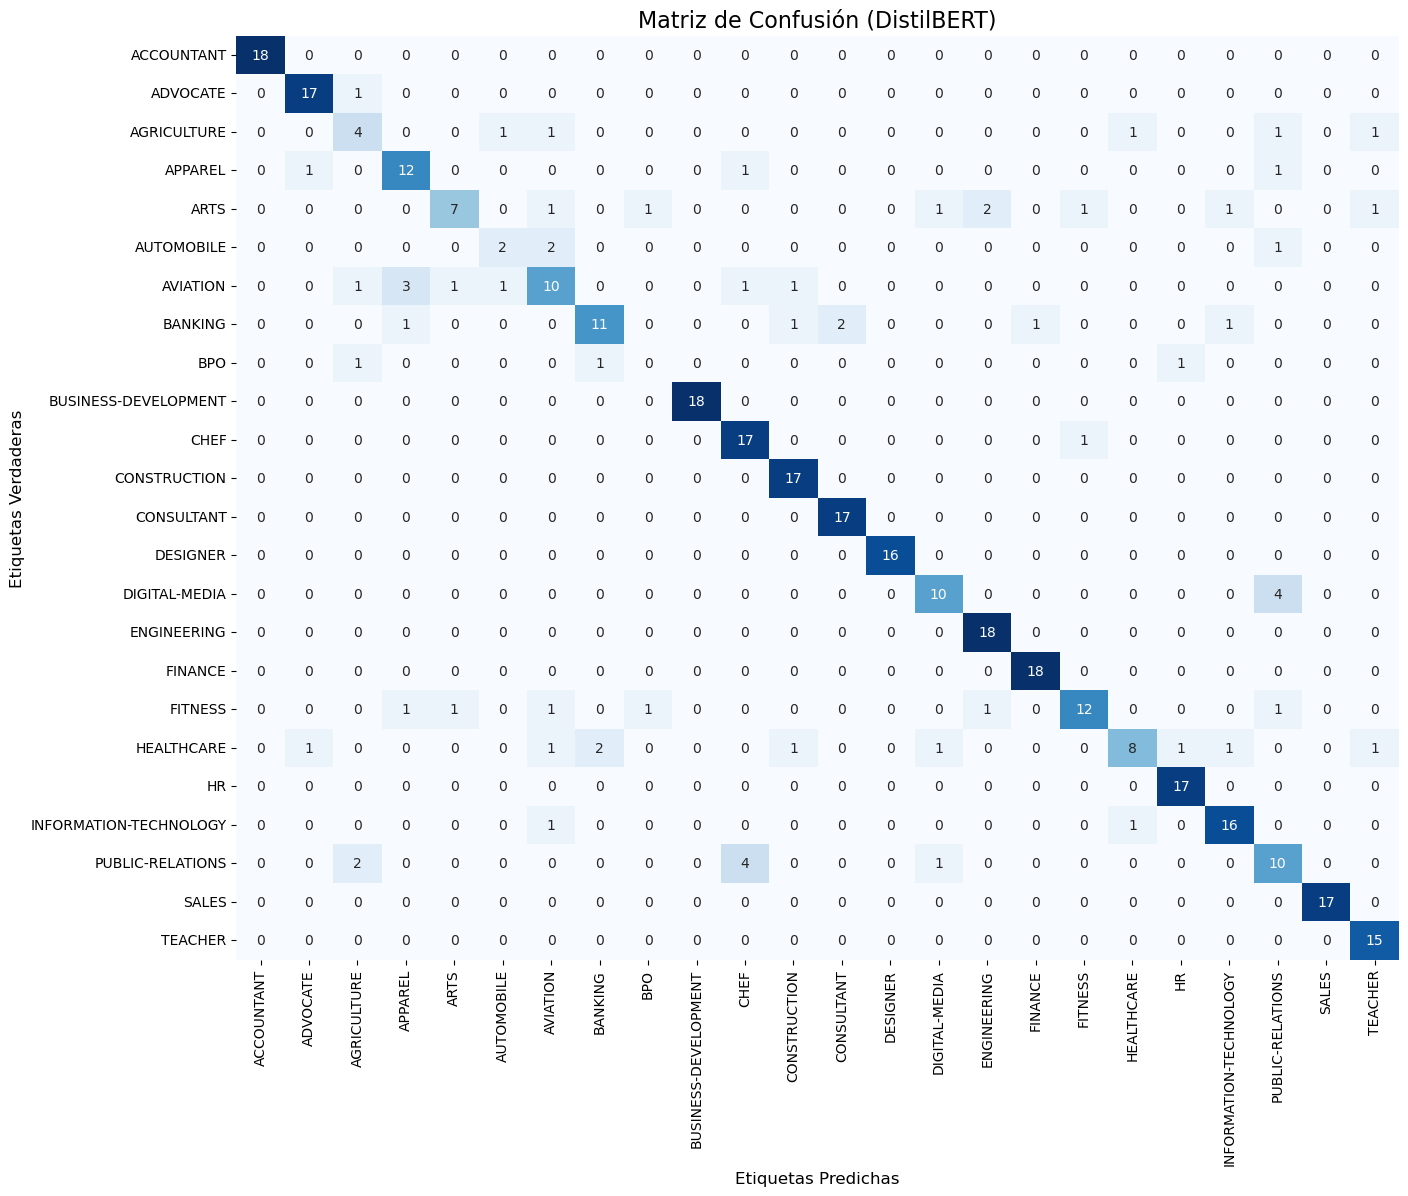

In [17]:
cm_distilbert = confusion_matrix(y_true_distil, y_pred_distil)

plt.figure(figsize=(15, 12))
sns.heatmap(
    cm_distilbert,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

try:
    plt.xticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=90)
    plt.yticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=0)
except NameError:
    pass

plt.xlabel("Etiquetas Predichas", fontsize=12)
plt.ylabel("Etiquetas Verdaderas", fontsize=12)
plt.title("Matriz de Confusión (DistilBERT)", fontsize=16)

plt.savefig("cm_distilbert_conteo.png", bbox_inches='tight')
plt.show()

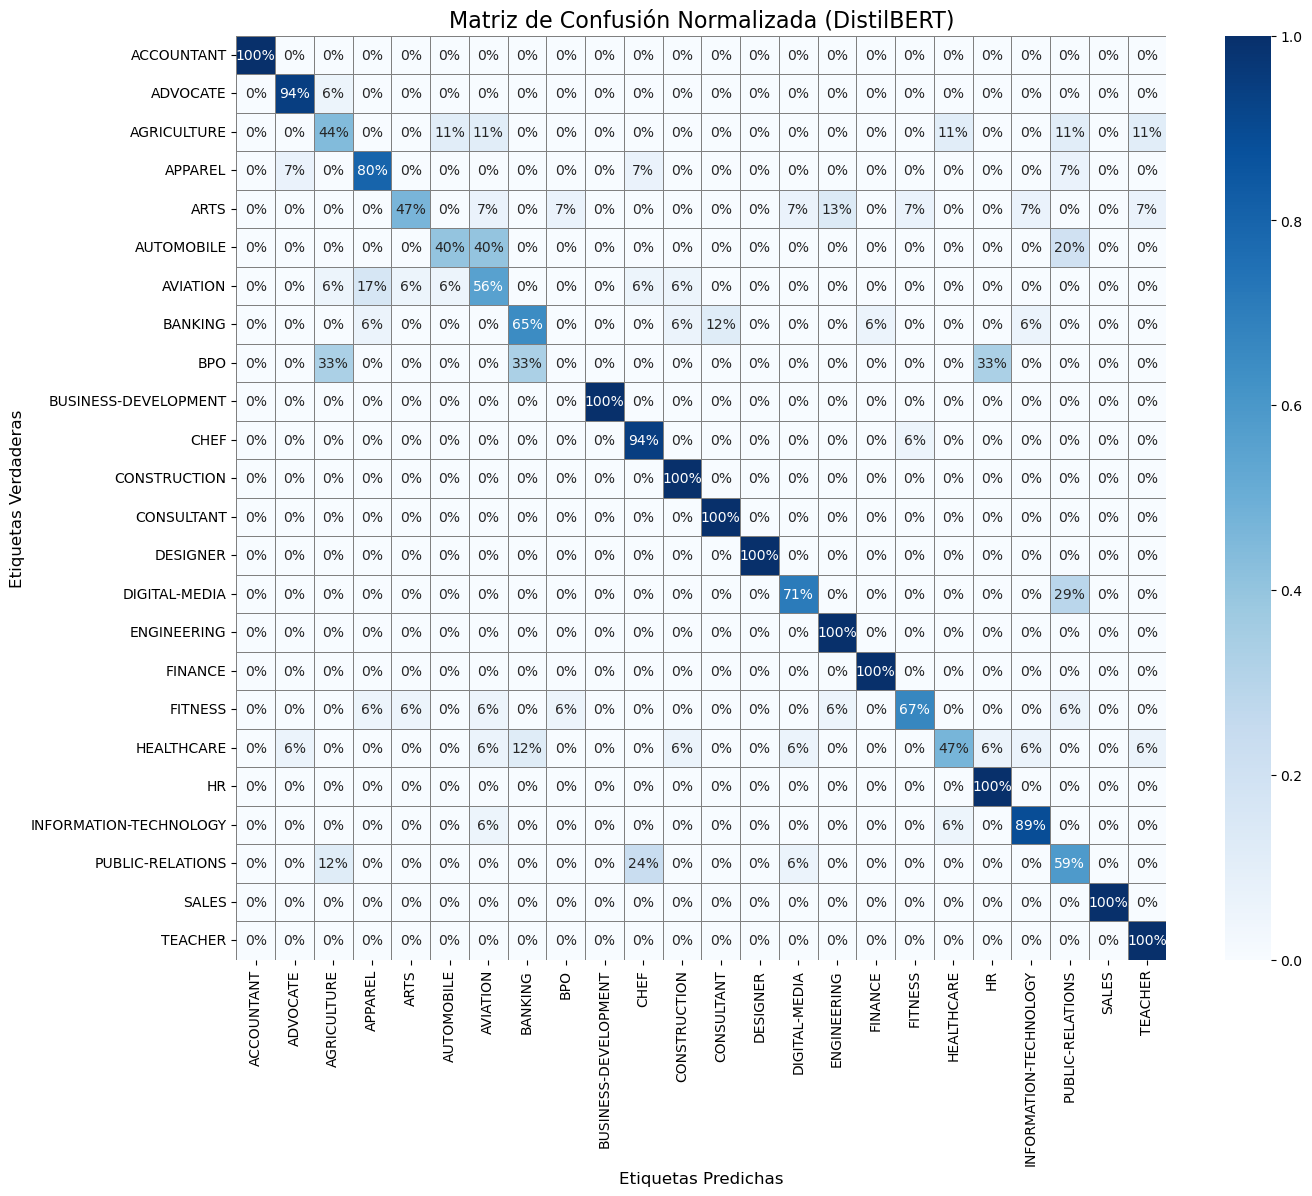

In [ ]:
cm_distilbert = confusion_matrix(y_true_distil, y_pred_distil)
cm_normalizada_distilbert = cm_distilbert.astype('float') / cm_distilbert.sum(axis=1)[:, np.newaxis]
cm_normalizada_distilbert = np.nan_to_num(cm_normalizada_distilbert)  # evitar NaN en clases sin muestras

plt.figure(figsize=(15, 12))
sns.heatmap(
    cm_normalizada_distilbert,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    cbar=True,
    linewidths=.5,
    linecolor='gray',
    annot_kws={"size":10}
)

try:
    plt.xticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=90)
    plt.yticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=0)
except NameError:
    pass

plt.xlabel("Etiquetas Predichas", fontsize=12)
plt.ylabel("Etiquetas Verdaderas", fontsize=12)
plt.title("Matriz de Confusión Normalizada (DistilBERT)", fontsize=16)

plt.savefig("cm_distilbert_normalizada.png", bbox_inches='tight')
plt.show()

En cuanto a las matrices de confusión, se puede afirmar que el modelo tuvo un buen rendimiento en general. De las **24** categorías, **17** lograron más del **60%** de clasificaciones correctas. De estas, **10** categorías alcanzaron un **100%** de aciertos y 2 categorías un **94%**, lo que evidencia que DistilBERT fue especialmente efectivo para un gran número de clases, aunque algunas categorías con menor representación todavía presentan oportunidades de mejora.

Cabe mencionar que para la categoría BPO, el modelo no logró acertar en ningún caso.

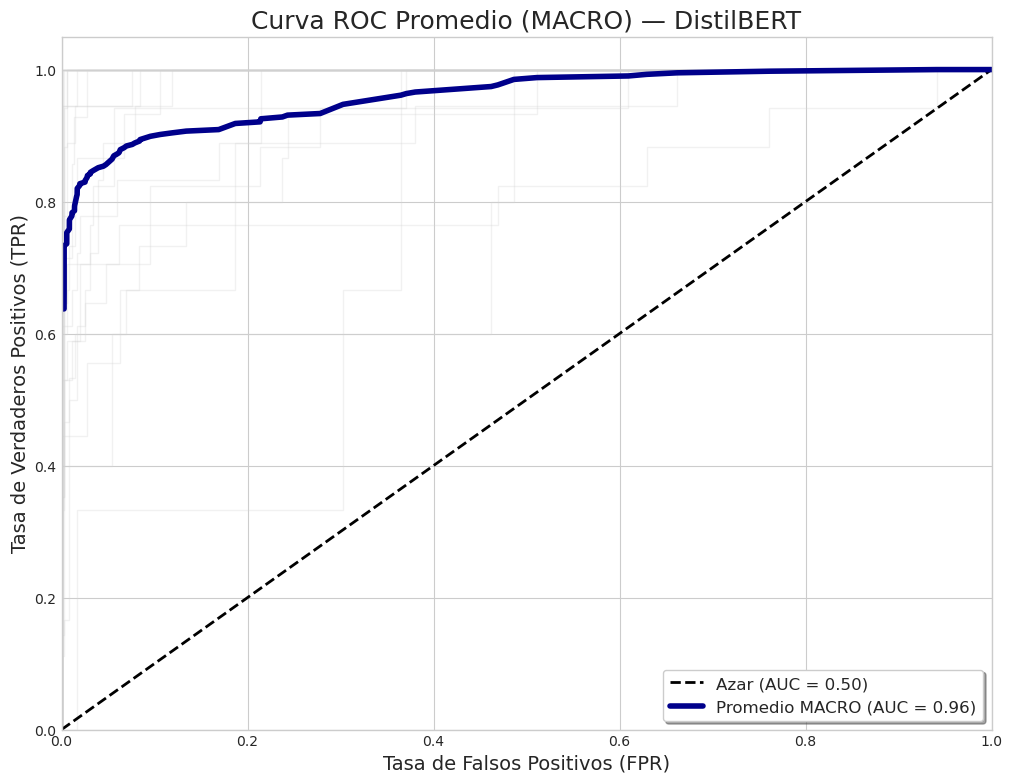

In [19]:
y_true_bin = label_binarize(y_true_distil, classes=np.arange(num_clases))
probs_matrix = y_pred_probs_distil  


fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_clases):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs_matrix[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_clases)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_clases):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_clases

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 9))

for i in range(num_clases):
    plt.plot(fpr[i], tpr[i], color='lightgray', alpha=0.3, lw=1)

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.50)')

plt.plot(
    fpr["macro"], tpr["macro"],
    label=f'Promedio MACRO (AUC = {roc_auc["macro"]:.2f})',
    color='darkblue', linestyle='-', linewidth=4
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('Curva ROC Promedio (MACRO) — DistilBERT', fontsize=18)
plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(True)

plt.savefig('curva_roc_general_distilbert.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_567/4180844656.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = itertools.cycle(plt.cm.get_cmap('tab20c').colors)


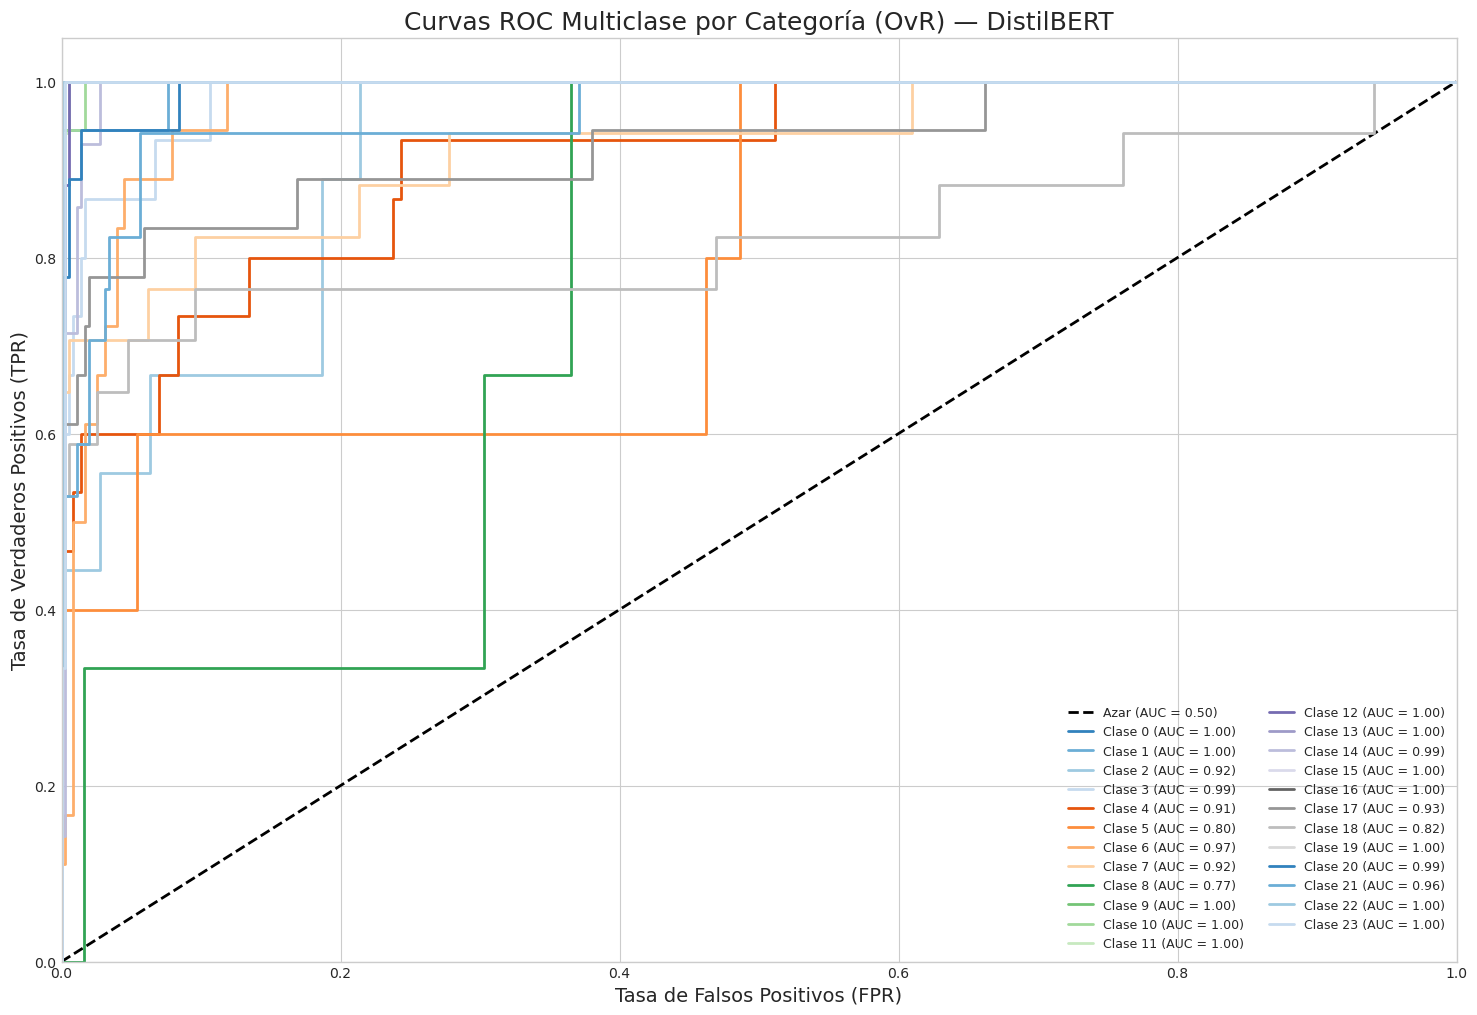

In [ ]:
plt.figure(figsize=(18, 12))
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.50)')

colors = itertools.cycle(plt.cm.get_cmap('tab20c').colors)

for i, color in zip(range(num_clases), colors):
    
    label_text = f'Clase {i}'
    
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{label_text} (AUC = {roc_auc[i]:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('Curvas ROC Multiclase por Categoría (OvR) — DistilBERT', fontsize=18)
plt.legend(loc="lower right", fontsize=9, ncol=2)
plt.grid(True)


plt.savefig('curva_roc_individual_distilbert.png', bbox_inches='tight')
plt.show()


Por otro lado, la curva ROC AUC promedio de **0.96** demuestra que el modelo tiene una buena capacidad de discriminación, tal como se había mencionado anteriormente. Además, al analizar las clases de manera individual, la mayoría obtuvo valores altos de AUC, que van principalmente de **0.9 a 1**, mientras que solo tres clases registraron valores menores, de **0.77, 0.8 y 0.82**, mostrando que la mayoría de las categorías se predicen con alta confiabilidad.

In [ ]:
import pickle

distilbert_info = {
    "model_path": best_model_dir,  # ruta al modelo DistilBERT guardado
    "metrics_test": {
        "Accuracy": accuracy_distil,
        "Precision (Macro)": precision_distil,
        "Recall (Macro)": recall_distil,
        "F1-Score (Macro)": f1_distil,
        "ROC AUC (Macro)": roc_auc_distil
    },
    "labels": {
        "y_true": y_true_distil,
        "y_pred": y_pred_distil
    }
}

summary_path = "distilbert_summary.pkl"
with open(summary_path, "wb") as f:
    pickle.dump(distilbert_info, f)

### **Modelo 2: Word2Vec + BiLSTM**

In [8]:
MAX_WORDS = 30000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 300
W2V_PATH = "../docs/GoogleNews-vectors-negative300.bin"

In [9]:
tokenizer_w2v = Tokenizer(num_words=MAX_WORDS, oov_token="<unk>")
tokenizer_w2v.fit_on_texts(train_df['Resume'])

X_train_seq_w2v = tokenizer_w2v.texts_to_sequences(train_df['Resume'])
X_val_seq_w2v   = tokenizer_w2v.texts_to_sequences(val_df['Resume'])
X_test_seq_w2v  = tokenizer_w2v.texts_to_sequences(test_df['Resume'])

X_train_pad_w2v = pad_sequences(X_train_seq_w2v, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_val_pad_w2v   = pad_sequences(X_val_seq_w2v,   maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad_w2v  = pad_sequences(X_test_seq_w2v,  maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')


y_train_w2v = train_df['Category'].astype(int).values
y_val_w2v   = val_df['Category'].astype(int).values
y_test_w2v  = test_df['Category'].astype(int).values

NUM_CLASSES = len(np.unique(y_train))

y_train_ohe_w2v = to_categorical(y_train_w2v, num_classes=NUM_CLASSES)
y_val_ohe_w2v  = to_categorical(y_val_w2v,   num_classes=NUM_CLASSES)
y_test_ohe_w2v  = to_categorical(y_test_w2v,  num_classes=NUM_CLASSES)

word_index_w2v = tokenizer_w2v.word_index
num_words_vocab_w2v = num_words_vocab_w2v = min(MAX_WORDS, len(word_index_w2v) + 1)
embedding_matrix_w2v = np.zeros((num_words_vocab_w2v, EMBEDDING_DIM), dtype=np.float32)

In [10]:
try:
    w2v_model = KeyedVectors.load_word2vec_format(W2V_PATH, binary=True, limit=500000)

    for word, i in word_index_w2v.items():
        if i >= num_words_vocab_w2v:
            continue
        if word in w2v_model:
            embedding_matrix_w2v[i] = w2v_model[word]
        elif word.lower() in w2v_model:
            embedding_matrix_w2v[i] = w2v_model[word.lower()]

    del w2v_model
except Exception as e:
    print("Error al cargar Word2Vec:", e)
    traceback.print_exc()
    
weights_w2v = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_train_w2v), y=y_train_w2v)
class_weights_dict_w2v = dict(zip(np.unique(y_train_w2v), weights_w2v))

In [11]:
def build_bilstm(params, embedding_matrix, input_length, num_classes):
    model = Sequential()
    model.add(Embedding(
        input_dim=embedding_matrix.shape[0],
        output_dim=embedding_matrix.shape[1],
        weights=[embedding_matrix],
        input_length=input_length,
        trainable=params['embedding_trainable']
    ))

    for layer_idx in range(params['num_lstm_layers']):
        return_seq = (layer_idx < params['num_lstm_layers'] - 1)
        model.add(Bidirectional(LSTM(params['lstm_units'], return_sequences=return_seq)))
        model.add(Dropout(params['dropout_rate']))

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(params['dropout_rate']))
    model.add(Dense(num_classes, activation='softmax'))

    opt = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

In [ ]:
param_grid_w2v = {
    'lstm_units': [32, 64],
    'num_lstm_layers': [1, 2],
    'dropout_rate': [0.3, 0.5],
    'learning_rate': [0.001, 0.005],
    'batch_size': [16, 32],
    'epochs': [20, 50],
    'embedding_trainable': [True]    
}

keys, values = zip(*param_grid_w2v.items())
all_combos = [dict(zip(keys, v)) for v in itertools.product(*values)]
random.seed(21)
MAX_TRIALS = 20
combos = random.sample(all_combos, min(MAX_TRIALS, len(all_combos)))

best_val_f1_w2v, best_model_w2v, best_params_w2v = 0, None, None
results_w2v = []

for i, params in enumerate(combos, 1):
    tf.keras.backend.clear_session()
    model_w2vbstm = build_bilstm(params, embedding_matrix_w2v, MAX_SEQUENCE_LENGTH, NUM_CLASSES)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0)
    ]

    model_w2vbstm.fit(
        X_train_pad_w2v, y_train_ohe_w2v,
        validation_data=(X_val_pad_w2v, y_val_ohe_w2v),
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        class_weight=class_weights_dict_w2v,
        callbacks=callbacks,
        verbose=0
    )

    val_probs_w2v = model_w2vbstm.predict(X_val_pad_w2v, verbose=0)
    val_preds_w2v = np.argmax(val_probs_w2v, axis=1)
    val_f1_w2v = f1_score(y_val_w2v, val_preds_w2v, average='macro')

    results_w2v.append((params, val_f1_w2v))

    if val_f1_w2v > best_val_f1_w2v:
        best_val_f1_w2v, best_model_w2v, best_params_w2v = val_f1_w2v, model_w2vbstm, params
        model_w2vbstm.save( "best_word2vec_bilstm.h5")


In [14]:
display(HTML("<h4>Mejores Hiperparámetros Encontrados:</h4>"))
params_df = pd.Series(best_params_w2v, name='Valor').to_frame()
params_df.index.name = 'Hiperparámetro'
display(params_df)

,Valor
Hiperparámetro,
lstm_units,64
num_lstm_layers,1
dropout_rate,0.3
learning_rate,0.001
batch_size,32
epochs,20
embedding_trainable,True


In [ ]:
results_w2v.sort(key=lambda x: x[1], reverse=True)
best_params_w2v, best_val_f1_w2v = results_w2v[0]

final_model_w2v = tf.keras.models.load_model('best_word2vec_bilstm.h5') 
seq_len_best = MAX_SEQUENCE_LENGTH
X_test_seq = X_test_pad_w2v 

loss_w2v, accuracy_w2v = final_model_w2v.evaluate(X_test_seq, y_test_ohe_w2v, verbose=0)
y_pred_probs_w2v = final_model_w2v.predict(X_test_seq, verbose=0)
y_pred_w2v = np.argmax(y_pred_probs_w2v, axis=1)
y_true_w2v = y_test_w2v

accuracy_w2v_t = accuracy_score(y_true_w2v, y_pred_w2v)
precision_w2v = precision_score(y_true_w2v, y_pred_w2v, average='macro')
recall_macro_w2v = recall_score(y_true_w2v, y_pred_w2v, average='macro')
f1_macro_w2v = f1_score(y_true_w2v, y_pred_w2v, average='macro')
roc_auc_macro_w2v = roc_auc_score(y_true_w2v, y_pred_probs_w2v, multi_class='ovr', average='macro')

results_final_w2v  = {
    'Accuracy': accuracy_w2v_t,
    'Precision (Macro)': precision_w2v,
    'F1-Score (Macro)': f1_macro_w2v,
    'Recall (Macro)': recall_macro_w2v,
    'ROC AUC (Macro)': roc_auc_macro_w2v
}

resultados['Word2Vec + BiLSTM'] = results_w2v

df_results_w2v = pd.DataFrame.from_dict(resultados, orient='index')
df_results_w2v.index.name = 'Modelo'
display(pd.DataFrame([results_final_w2v ], index=['Word2Vec + BiLSTM']))

,Accuracy,Precision (Macro),F1-Score (Macro),Recall (Macro),ROC AUC (Macro)
Word2Vec + BiLSTM,0.756032,0.702512,0.696467,0.705388,0.945301


El modelo Word2Vec + BiLSTM mostró un desempeño consistente en el conjunto de prueba. Alcanzó una accuracy de **75.6%** y un F1-Score macro de **69.6%**, lo que indica un buen equilibrio entre precisión y recall en todas las clases. Además, su ROC AUC macro de **0.945** refleja que el modelo tiene una buena capacidad para diferenciar entre las categorías.

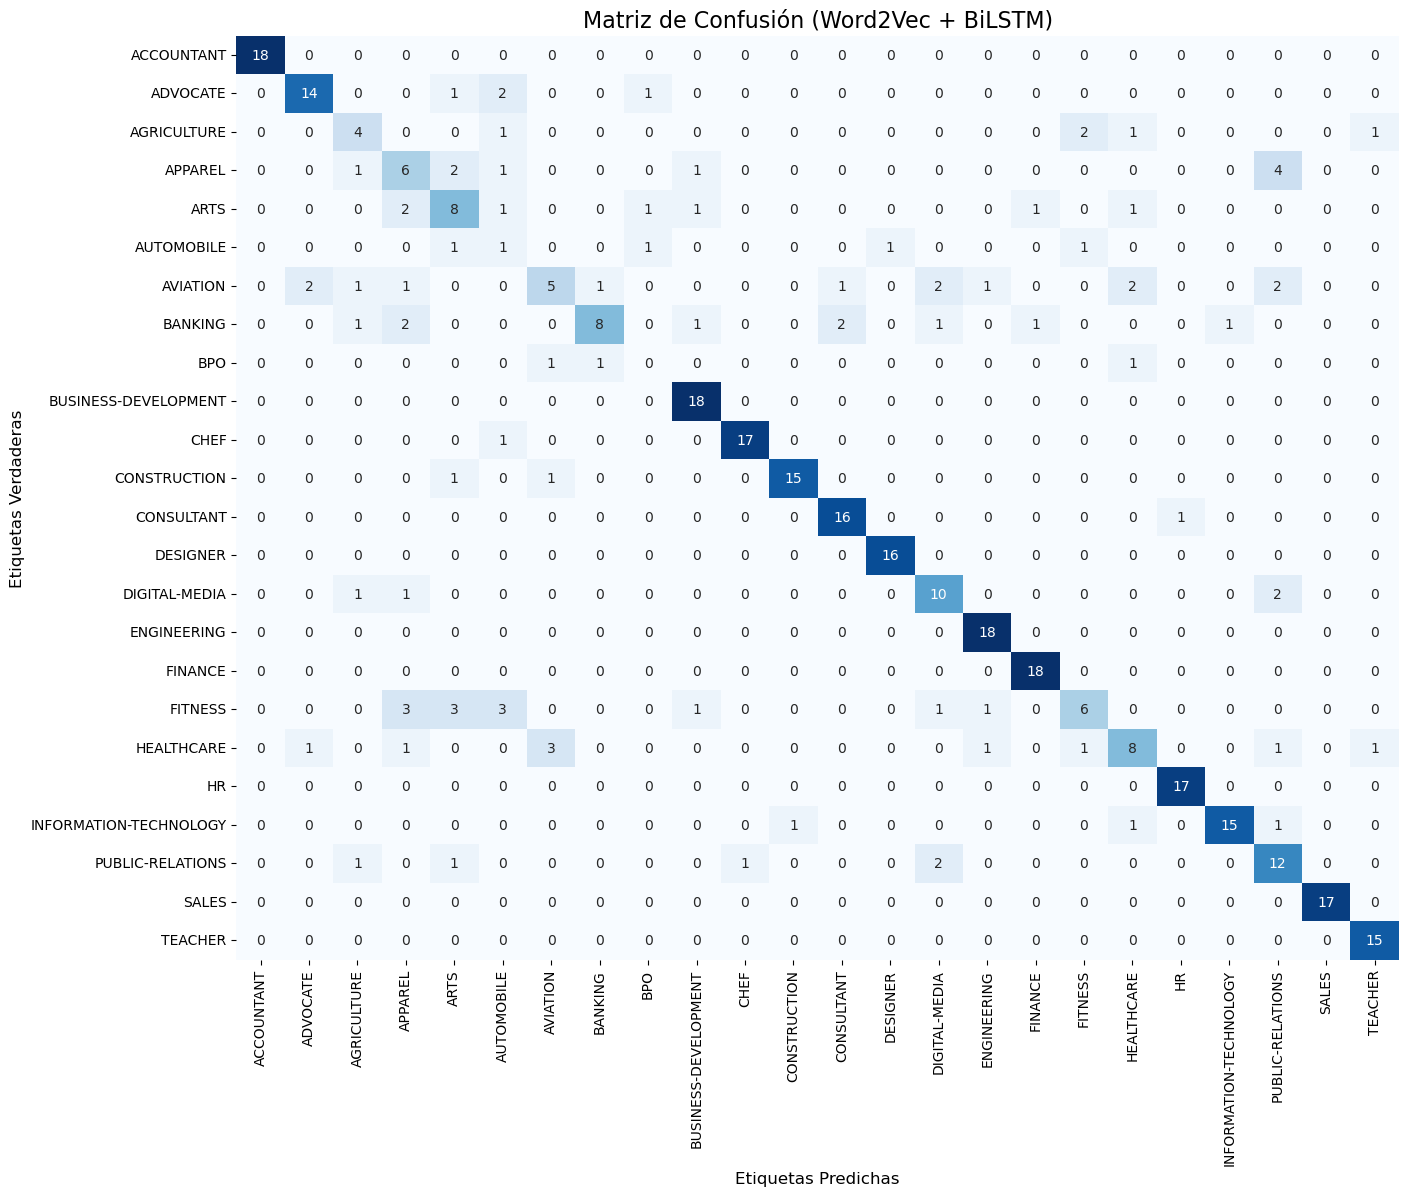

In [18]:
cm_w2v = confusion_matrix(y_true_w2v, y_pred_w2v)

plt.figure(figsize=(15, 12))
sns.heatmap(
    cm_w2v, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    cbar=False
)

try:
    plt.xticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=90)
    plt.yticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=0)
except NameError:
    pass

plt.xlabel("Etiquetas Predichas", fontsize=12)
plt.ylabel("Etiquetas Verdaderas", fontsize=12)
plt.title("Matriz de Confusión (Word2Vec + BiLSTM)", fontsize=16)

plt.savefig('cm_conteo_w2v.png', bbox_inches='tight')

plt.show()

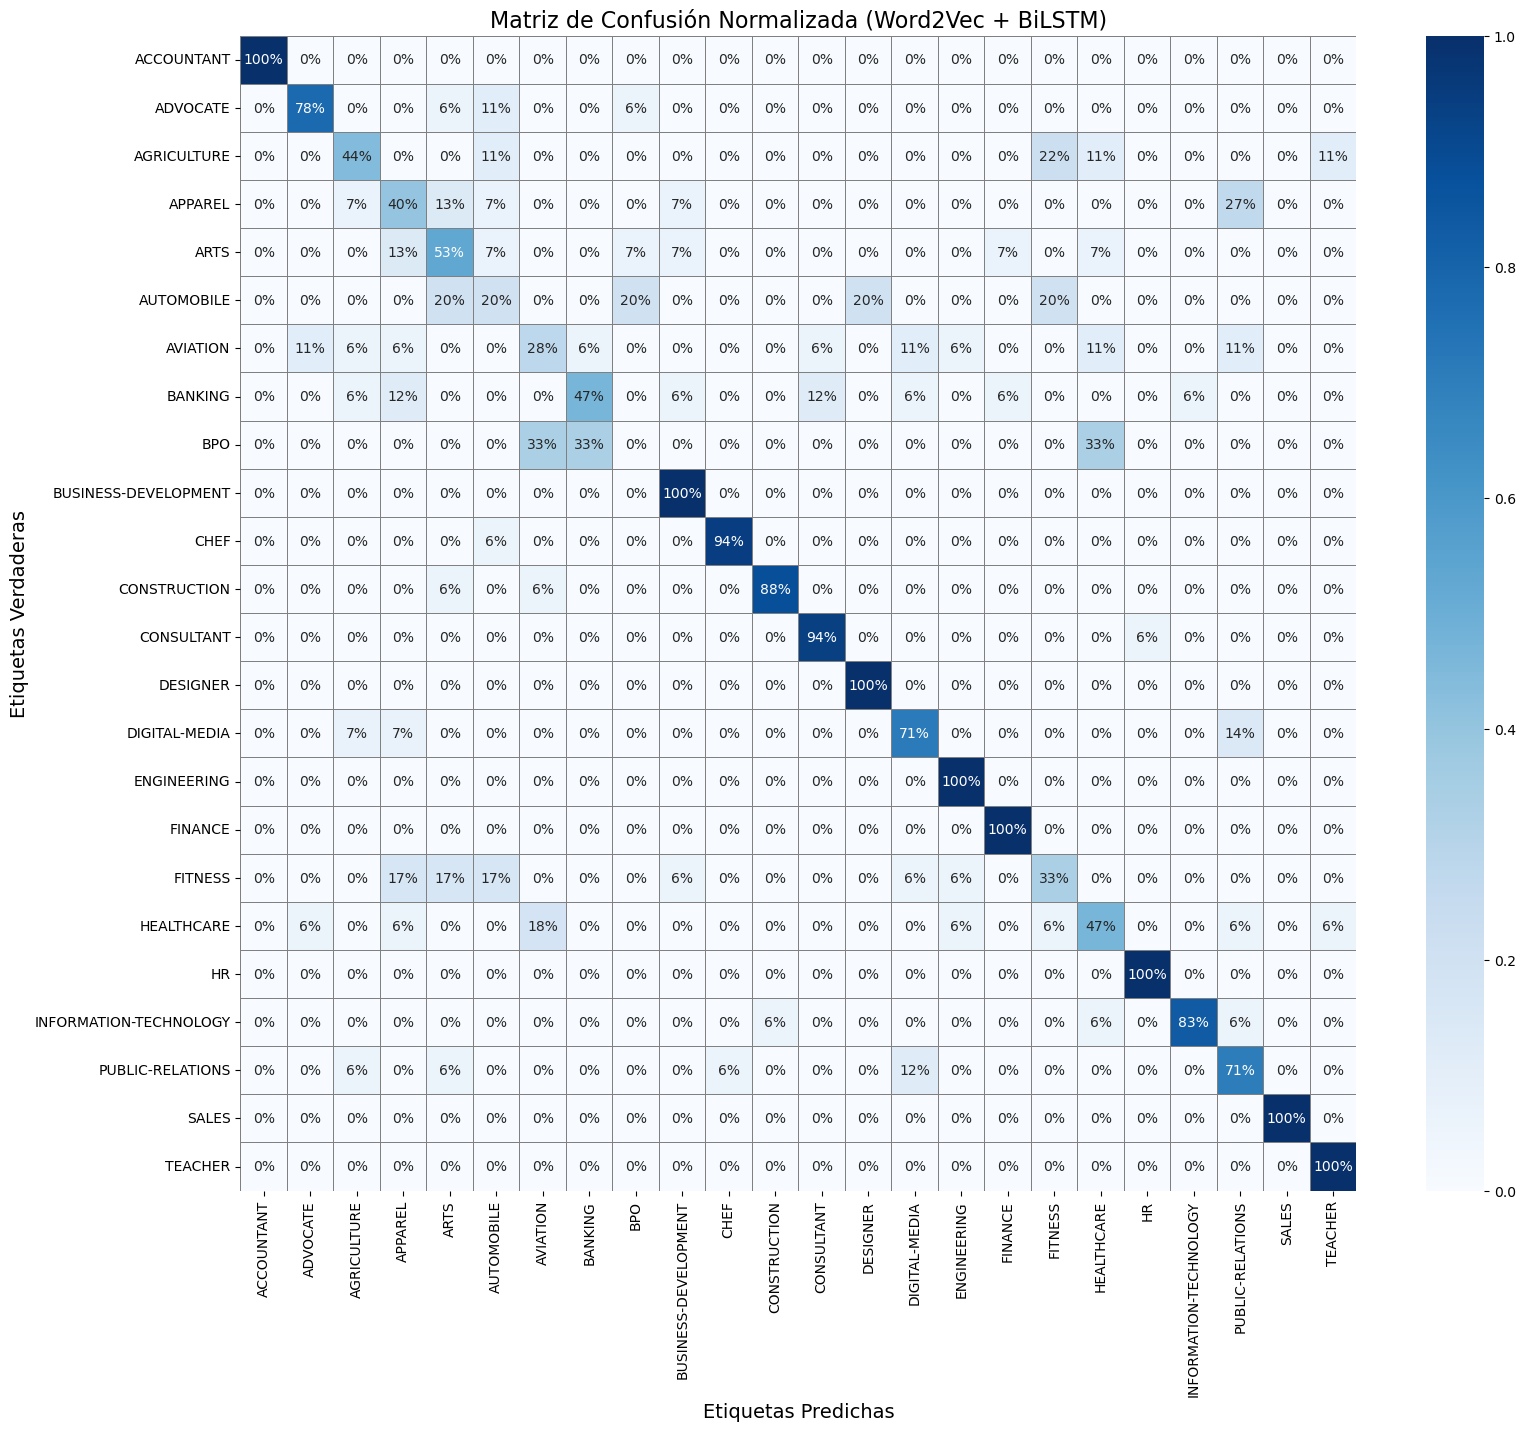

In [19]:
cm_normalized_w2v = cm_w2v.astype('float') / cm_w2v.sum(axis=1)[:, np.newaxis]
cm_normalized_w2v = np.nan_to_num(cm_normalized_w2v) 

plt.figure(figsize=(18, 15)) 

sns.heatmap(
    cm_normalized_w2v,           
    annot=True,              
    fmt='.0%',               
    cmap='Blues',            
    cbar=True,               
    linewidths=.5,           
    linecolor='gray',        
    annot_kws={"size": 10}  
)

try:
    plt.xticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=90)
    plt.yticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=0)
except NameError:
    pass

plt.xlabel("Etiquetas Predichas", fontsize=14)
plt.ylabel("Etiquetas Verdaderas", fontsize=14)
plt.title("Matriz de Confusión Normalizada (Word2Vec + BiLSTM)", fontsize=16)

plt.savefig('cm_normalizada_w2v.png', bbox_inches='tight') 

plt.show()

En cuanto a las matrices de confusión, se puede afirmar que el modelo tuvo un rendimiento considerable. De las **24** categorías, **15** lograron más del **60%** de clasificaciones correctas; de estas, **8** alcanzaron un **100%** de aciertos y **2** un **94%**. Sin embargo, también se observan categorías con valores bajos en la diagonal, incluso alrededor del **20%**, lo que evidencia que el modelo no siempre fue tan preciso para todas las clases. Sobretodo para BPO, para la cual no clasificó ninguna correctamente.

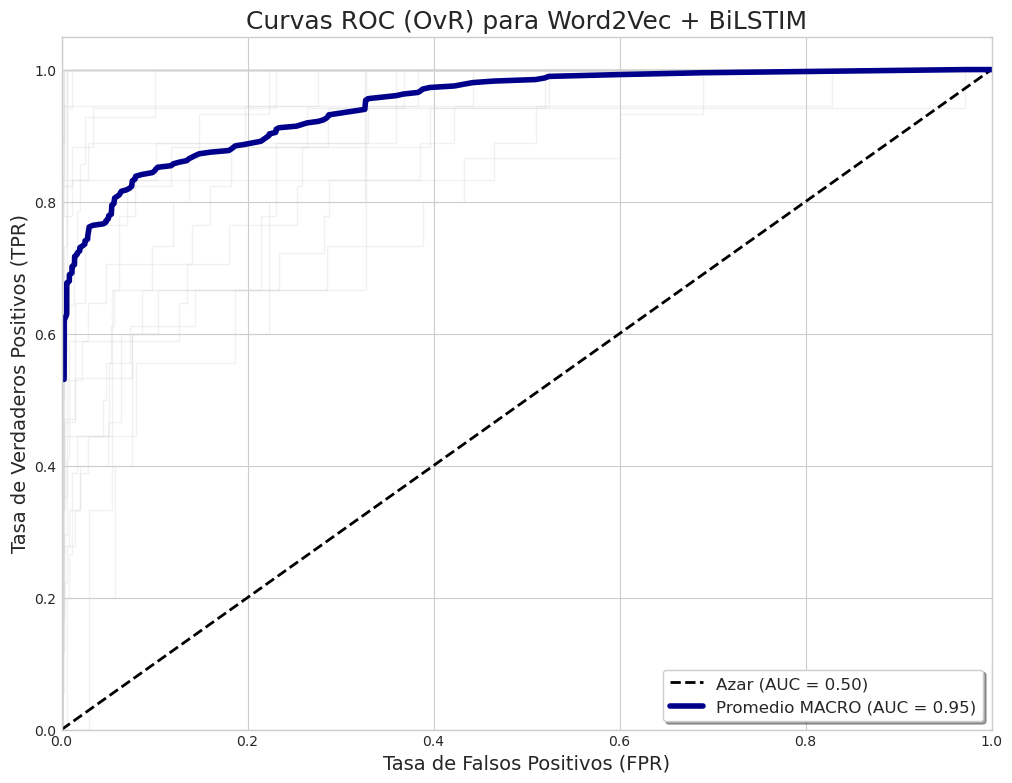

In [20]:
y_true_binarized_w2v = label_binarize(y_true_w2v, classes=np.arange(num_clases))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_clases):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized_w2v[:, i], y_pred_probs_w2v[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_clases)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_clases):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_clases 
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.style.use('seaborn-v0_8-whitegrid') 
plt.figure(figsize=(12, 9))

for i in range(num_clases):
    plt.plot(fpr[i], tpr[i], 
             color='lightgray', 
             alpha=0.3,       
             lw=1)            

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.50)')

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label=f'Promedio MACRO (AUC = {roc_auc["macro"]:.2f})', 
    color='darkblue',    
    linestyle='-',       
    linewidth=4          
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('Curvas ROC (OvR) para Word2Vec + BiLSTIM', fontsize=18)

plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(True)

plt.savefig('curva_roc_general_w2v.png', bbox_inches='tight')

plt.show()

/tmp/ipykernel_2002/2325955554.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = itertools.cycle(plt.cm.get_cmap('tab20c').colors)


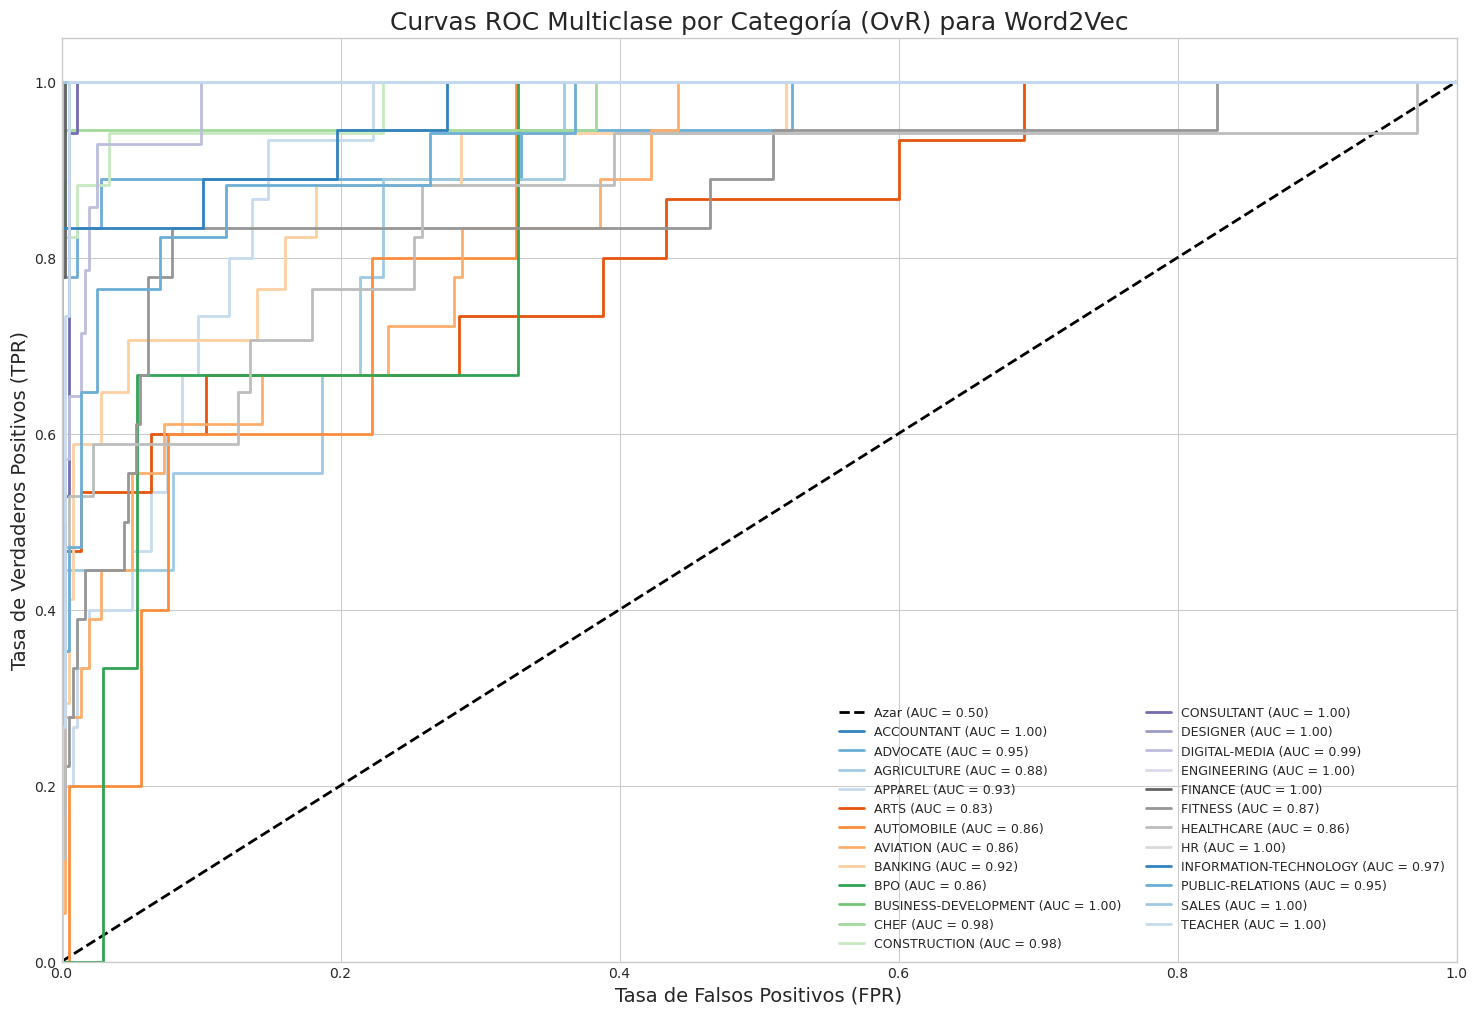

In [21]:
for i in range(num_clases):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized_w2v[:, i], y_pred_probs_w2v[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(18, 12)) 

colors = itertools.cycle(plt.cm.get_cmap('tab20c').colors)
plt.style.use('seaborn-v0_8-whitegrid') 

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.50)')

for i, color in zip(range(num_clases), colors):
    
    try:
        label_text = categorias[i]
    except (NameError, IndexError):
        label_text = f'Clase {i}'
        
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{label_text} (AUC = {roc_auc[i]:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('Curvas ROC Multiclase por Categoría (OvR) para Word2Vec', fontsize=18)

plt.legend(loc="lower right", fontsize=9, ncol=2) 
plt.grid(True)

plt.savefig('curva_roc_indvidual_w2v.png', bbox_inches='tight')
plt.show()

Por otra parte, la curva ROC AUC promedio de **0.95** indica que el modelo posee una buena capacidad para distinguir entre las diferentes clases. Al evaluar las clases de forma individual, la mayoría mostró valores de AUC altos, que van de **0.83** a **1**, lo que refleja que la mayoría de las categorías se clasifican con un nivel elevado de confiabilidad.

In [24]:
model_path_w2v = "best_word2vec_bilstm.h5"
best_model_w2v.save(model_path_w2v)

word2vec_info = {

    "model_path": model_path_w2v,

    "best_params": best_params_w2v,

    "metrics_test": {
        "Accuracy": accuracy_w2v_t,
        "Precision (Macro)": precision_w2v,
        "Recall (Macro)": recall_macro_w2v,
        "F1-Score (Macro)": f1_macro_w2v,
        "ROC AUC (Macro)": roc_auc_macro_w2v
    },

    # Etiquetas reales vs predichas
    "labels": {
        "y_true": y_test_w2v.tolist() if hasattr(y_test_w2v, 'tolist') else y_test_w2v,
        "y_pred": y_pred_w2v.tolist() if hasattr(y_pred_w2v, 'tolist') else y_pred_w2v
    }
}

summary_path_w2v = "word2vec_info.pkl"

with open(summary_path_w2v, "wb") as f:
    pickle.dump(word2vec_info, f, protocol=pickle.HIGHEST_PROTOCOL)

### **Modelo 3: CNN-1D**

In [10]:
max_words_cnn = 30000
max_sequence_length_cnn = 200
embedding_dim_cnn = 100  

tokenizer_cnn = Tokenizer(num_words=max_words_cnn, oov_token="<unk>")
tokenizer_cnn.fit_on_texts(X_train)
word_index_cnn = tokenizer_cnn.word_index
num_words_vocab_cnn = min(max_words_cnn, len(word_index_cnn) + 1)

seq_train_cnn = tokenizer_cnn.texts_to_sequences(X_train)
seq_val_cnn   = tokenizer_cnn.texts_to_sequences(X_val)
seq_test_cnn  = tokenizer_cnn.texts_to_sequences(X_test)

X_train_pad_cnn = pad_sequences(seq_train_cnn, maxlen=max_sequence_length_cnn, padding='post', truncating='post')
X_val_pad_cnn   = pad_sequences(seq_val_cnn,   maxlen=max_sequence_length_cnn, padding='post', truncating='post')
X_test_pad_cnn = pad_sequences(seq_test_cnn,  maxlen=max_sequence_length_cnn, padding='post', truncating='post')

In [ ]:
glove_path = "../docs/wiki_giga_2024_100_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05.050_combined.txt"
embeddings_index_cnn = {}
try:
    with open(glove_path, encoding="utf8") as f:
        for line in f:
            values = line.rstrip().split(" ")
            word = values[0]
            coeffs = np.asarray(values[1:], dtype="float32")
            embeddings_index_cnn[word] = coeffs
except Exception as e:
    print(f"Error al cargar GloVe: {e}")

embedding_matrix_cnn = np.zeros((num_words_vocab_cnn, embedding_dim_cnn), dtype=np.float32)
for word, i in word_index_cnn.items():
    if i >= num_words_vocab_cnn: 
        continue
    vector = embeddings_index_cnn.get(word)
    if vector is not None:
        embedding_matrix_cnn[i] = vector

In [12]:
def build_cnn_model(embedding_matrix_cnn, num_classes_cnn, max_sequence_length_cnn, hp):
    filters = hp['num_filters']
    kernel_size = hp['kernel_size']
    dropout_rate = hp['dropout_rate']
    lr = hp['learning_rate']
    
    input_layer = Input(shape=(max_sequence_length_cnn,), dtype='int32')
    embedding_layer = Embedding(
        input_dim=embedding_matrix_cnn.shape[0],
        output_dim=embedding_matrix_cnn.shape[1],
        weights=[embedding_matrix_cnn],
        input_length=max_sequence_length_cnn,
        trainable=True  
    )(input_layer)

    conv_blocks = []
    for ks in [kernel_size, kernel_size + 1, kernel_size + 2]:
        conv = Conv1D(filters=filters, kernel_size=ks, activation='relu')(embedding_layer)
        pool = GlobalMaxPooling1D()(conv)
        conv_blocks.append(pool)

    concatenated = concatenate(conv_blocks)
    dense_1 = Dense(filters * 2, activation='relu')(concatenated)
    dropout_1 = Dropout(dropout_rate)(dense_1)
    output_layer = Dense(num_classes_cnn, activation='softmax')(dropout_1)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=Adam(learning_rate=lr),
                  metrics=['accuracy'])
    return model

In [ ]:
param_grid_cnn = {
    'num_filters': [64, 128, 256],
    'kernel_size': [3, 5],
    'dropout_rate': [0.3, 0.5],
    'learning_rate': [0.001, 0.005],
    'batch_size': [32, 64],
    'epochs': [50, 100]
}

keys, values = zip(*param_grid_cnn.items())
all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
random.seed(21)
MAX_TRIALS = 30
combos = random.sample(all_combinations, min(MAX_TRIALS, len(all_combinations)))

best_val_f1_cnn = 0
best_model_cnn = None
best_params_cnn = None
model_save_path_cnn = 'cnn1d_glove_best.h5'


for i, params in enumerate(combos, 1):

    model_cnn = build_cnn_model(embedding_matrix_cnn, num_clases, max_sequence_length_cnn, params)
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0)
    ]

    history = model_cnn.fit(
        X_train_pad_cnn, y_train,
        validation_data=(X_val_pad_cnn, y_val),
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        callbacks=callbacks,
        verbose=0
    )

    y_pred_probs_cnn_v = model_cnn.predict(X_val_pad_cnn, verbose=0)
    y_pred_classes_cnn = np.argmax(y_pred_probs_cnn_v, axis=1)
    val_f1_cnn = f1_score(y_val, y_pred_classes_cnn, average='macro', zero_division=0)

    if val_f1_cnn > best_val_f1_cnn:
        best_val_f1_cnn = val_f1_cnn
        best_model_cnn = model_cnn
        best_params_cnn = params
        best_model_cnn.save(model_save_path_cnn)

In [34]:
display(HTML("<h4>Mejores Hiperparámetros Encontrados:</h4>"))
params_df = pd.Series(best_params_cnn, name='Valor').to_frame()
params_df.index.name = 'Hiperparámetro'
display(params_df)

,Valor
Hiperparámetro,
num_filters,256.000
kernel_size,3.000
dropout_rate,0.300
learning_rate,0.001
batch_size,64.000
epochs,100.000


In [ ]:
final_cnn_model = load_model(model_save_path_cnn)

X_test_seq_cnn = X_test_pad_cnn
y_true_cnn = y_test

y_pred_probs_cnn = final_cnn_model.predict(X_test_seq_cnn, verbose=0)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

accuracy_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
f1_macro_cnn = f1_score(y_true_cnn, y_pred_cnn, average='macro', zero_division=0)
recall_macro_cnn = recall_score(y_true_cnn, y_pred_cnn, average='macro', zero_division=0)
precision_macro_cnn = precision_score(y_true_cnn, y_pred_cnn, average='macro', zero_division=0)
roc_auc_macro_cnn = roc_auc_score(y_true_cnn, y_pred_probs_cnn, multi_class='ovr', average='macro')

results_cnn = {
    'Accuracy': accuracy_cnn,
    'Precision (Macro)': precision_macro_cnn,
    'F1-Score (Macro)': f1_macro_cnn,
    'Recall (Macro)': recall_macro_cnn,
    'ROC AUC (Macro)': roc_auc_macro_cnn
}

resultados['CNN-1D'] = results_cnn

df_results_cnn = pd.DataFrame.from_dict(resultados, orient='index')
df_results_cnn.index.name = 'Modelo'
display(pd.DataFrame([results_cnn], index=['CNN-1D']))

,Accuracy,Precision (Macro),F1-Score (Macro),Recall (Macro),ROC AUC (Macro)
CNN-1D,0.788204,0.7643,0.739106,0.740643,0.960109


El modelo CNN-1D mostró un desempeño consistente en el conjunto de prueba, con una accuracy de **0.7882**. Su F1-Score macro de **0.7391** indica un equilibrio sólido entre precisión y recall a lo largo de todas las categorías. Además, el ROC AUC macro de **0.9601** refleja que el modelo logra diferenciar correctamente entre la mayoría de clases, mostrando confiabilidad incluso en aquellas con menor representación.

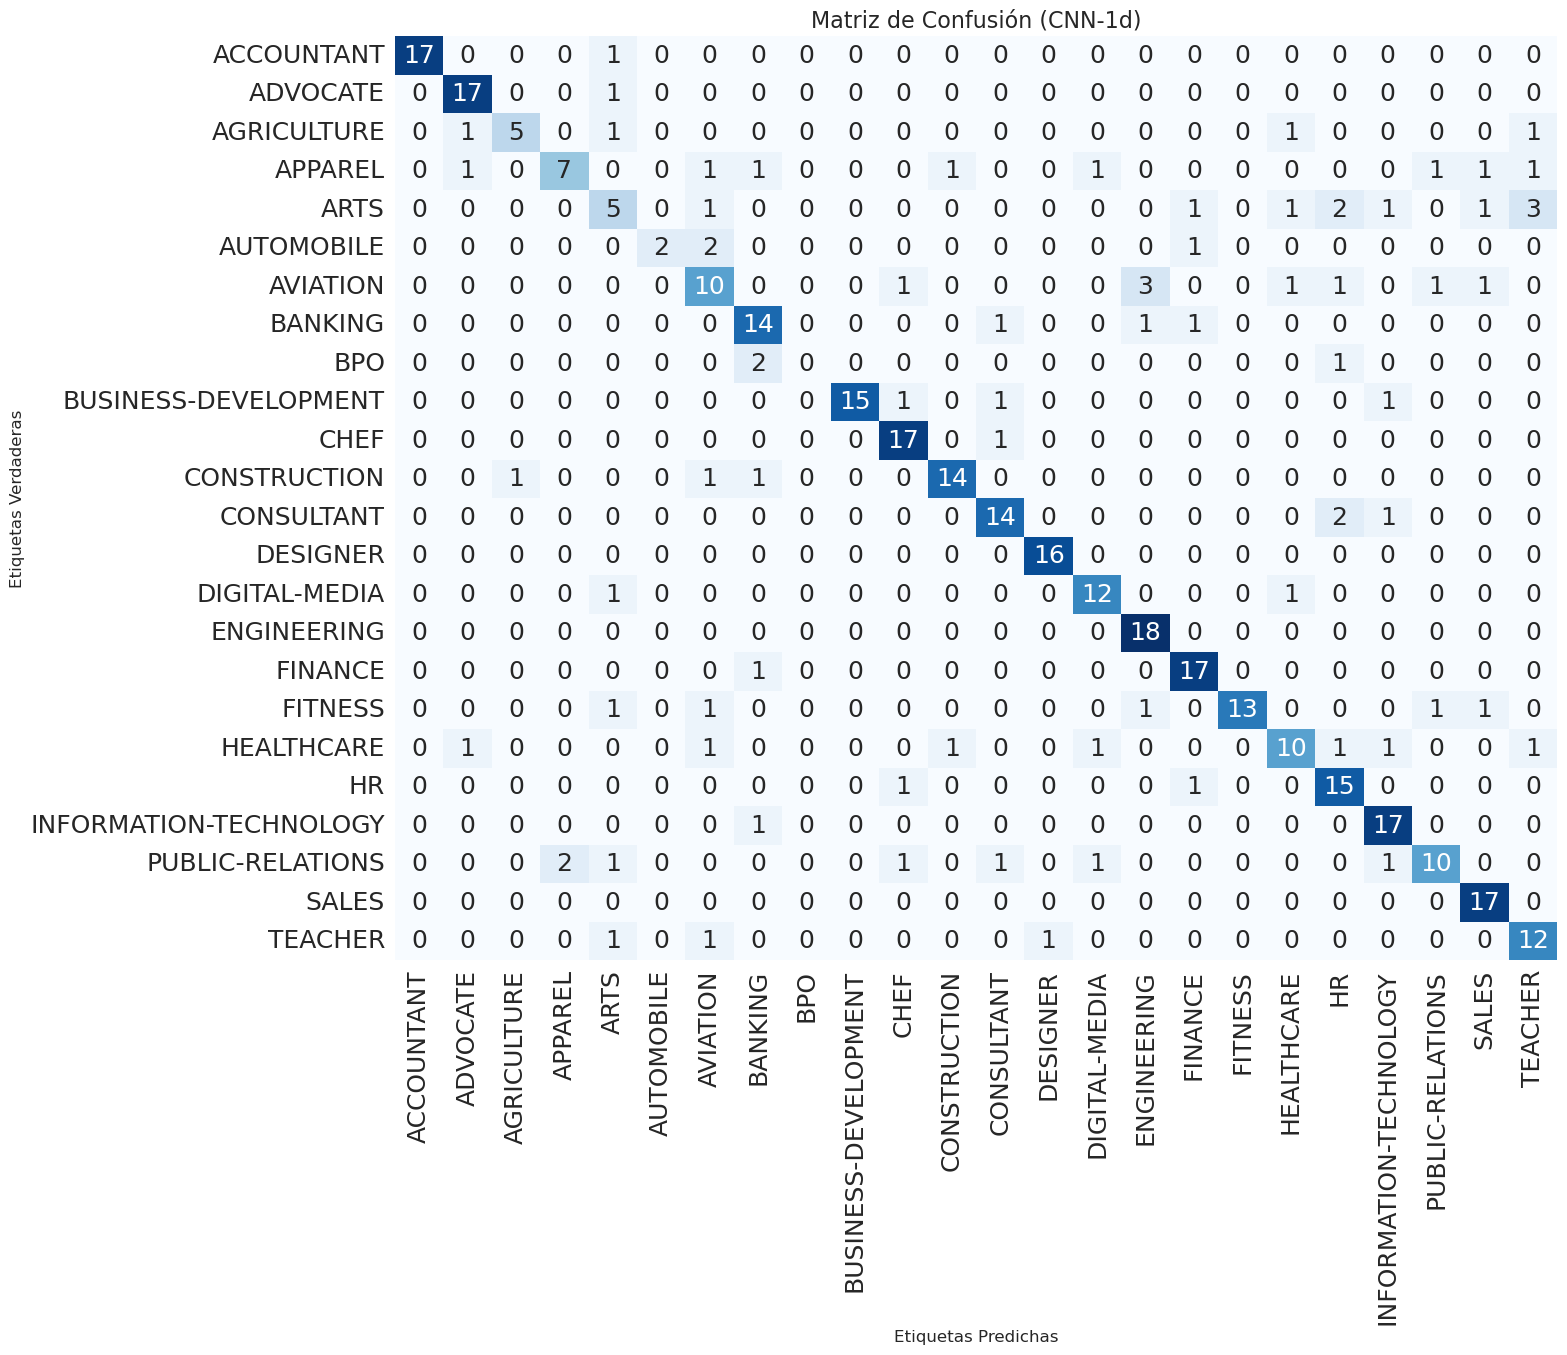

In [16]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(15, 12))
sns.heatmap(
    cm_cnn, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    cbar=False
)

try:
    plt.xticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=90)
    plt.yticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=0)
except NameError:
    pass

plt.xlabel("Etiquetas Predichas", fontsize=12)
plt.ylabel("Etiquetas Verdaderas", fontsize=12)
plt.title("Matriz de Confusión (CNN-1d)", fontsize=16)

plt.savefig('cm_conteo_cnn.png', bbox_inches='tight')

plt.show()

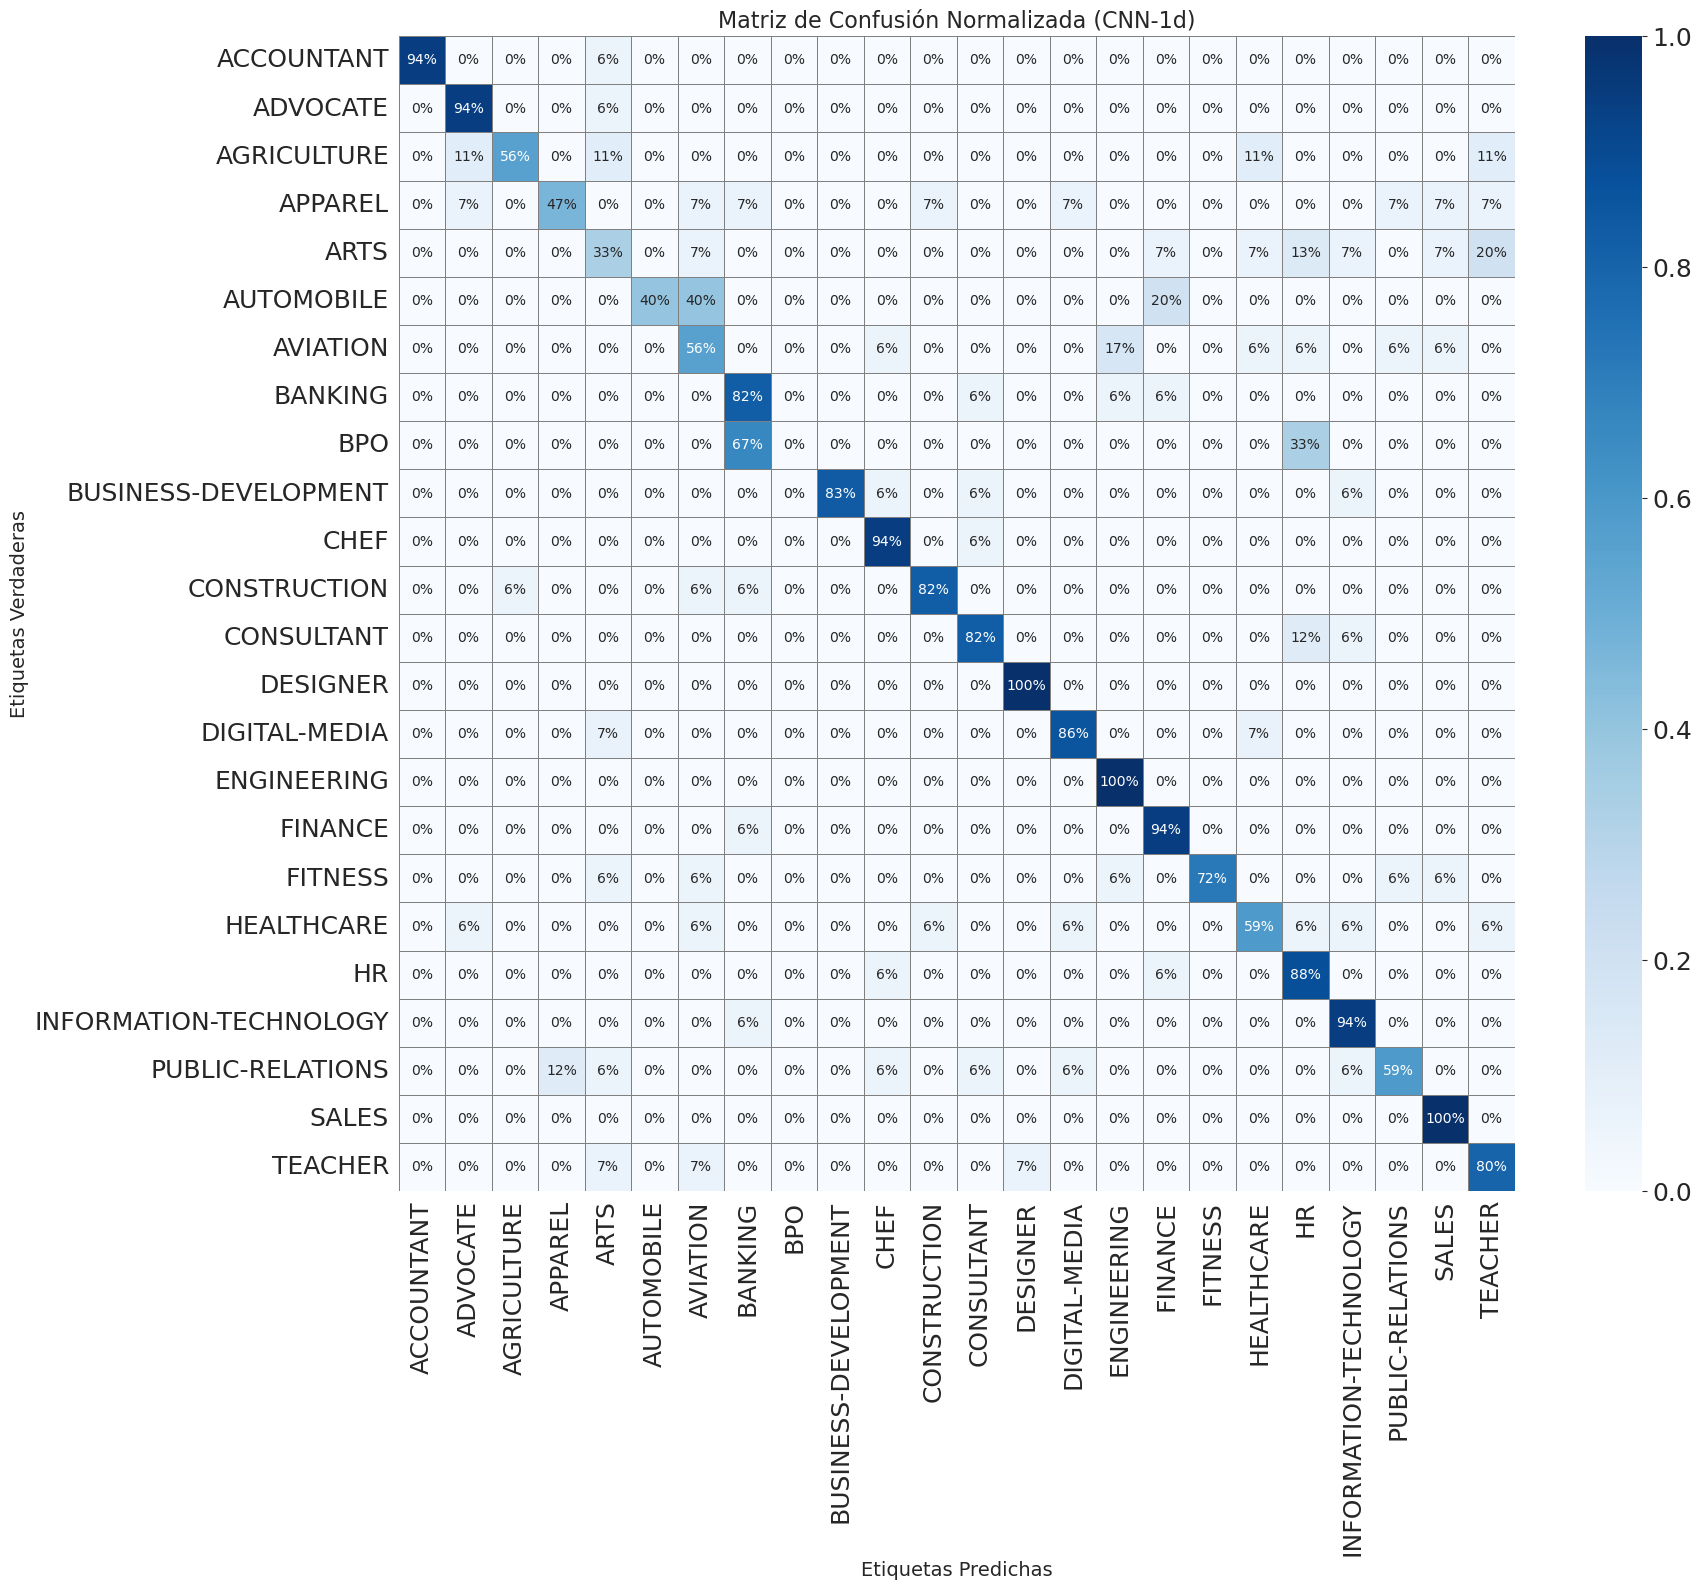

In [17]:
cm_normalized_cnn = cm_cnn.astype('float') / cm_cnn.sum(axis=1)[:, np.newaxis]
cm_normalized_cnn = np.nan_to_num(cm_normalized_cnn) 

plt.figure(figsize=(18, 15)) 

sns.heatmap(
    cm_normalized_cnn,           
    annot=True,              
    fmt='.0%',               
    cmap='Blues',            
    cbar=True,               
    linewidths=.5,           
    linecolor='gray',        
    annot_kws={"size": 10}  
)

try:
    plt.xticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=90)
    plt.yticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=0)
except NameError:
    pass

plt.xlabel("Etiquetas Predichas", fontsize=14)
plt.ylabel("Etiquetas Verdaderas", fontsize=14)
plt.title("Matriz de Confusión Normalizada (CNN-1d)", fontsize=16)

plt.savefig('cm_normalizada_cnn.png', bbox_inches='tight') 

plt.show()

Analizando las matrices de confusión, se puede ver que el modelo alcanzó un desempeño notable en general. De las **24** categorías, **16** lograron superar el **60%** de clasificaciones correctas; dentro de estas, **3** lograron un **100%** de aciertos y **5** un **94%**, mientras que varias otras superaron el **80%**. Aun así, algunas clases presentan valores bajos en la diagonal, lo que indica que el modelo no siempre logró predecir correctamente todas las categorías.

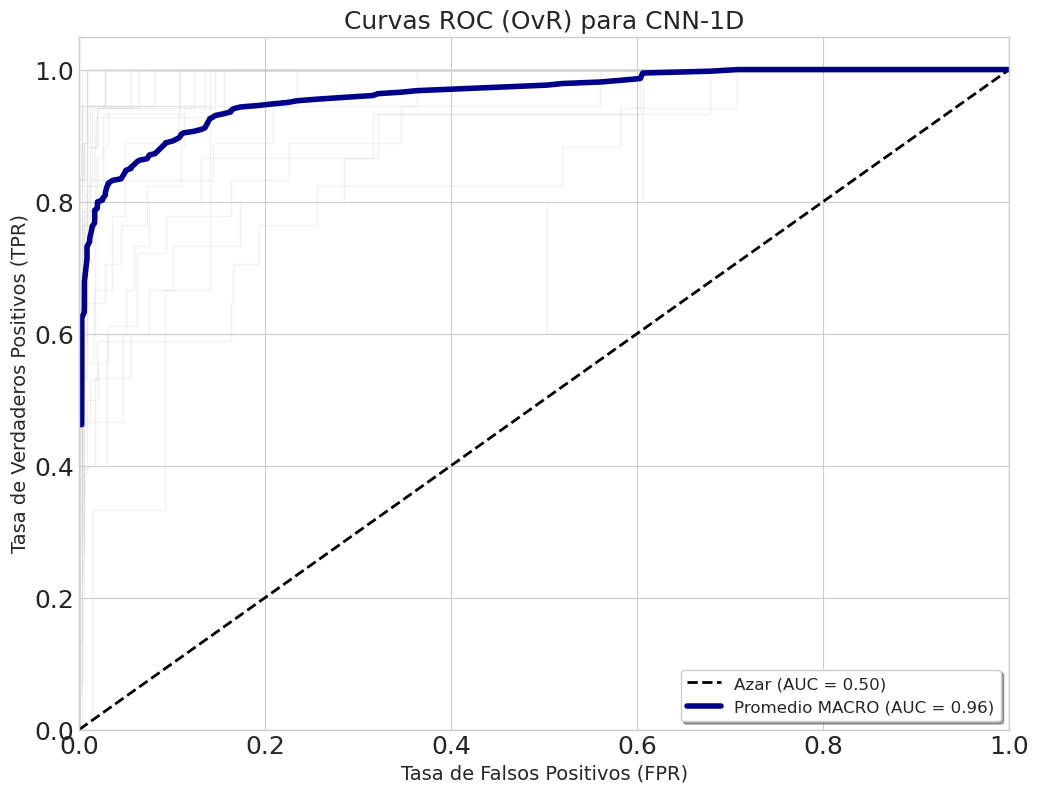

In [18]:
y_true_binarized_cnn = label_binarize(y_true_cnn, classes=np.arange(num_clases))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_clases):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized_cnn[:, i], y_pred_probs_cnn[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_clases)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_clases):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_clases 
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.style.use('seaborn-v0_8-whitegrid') 
plt.figure(figsize=(12, 9))

for i in range(num_clases):
    plt.plot(fpr[i], tpr[i], 
             color='lightgray', 
             alpha=0.3,       
             lw=1)            

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.50)')

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label=f'Promedio MACRO (AUC = {roc_auc["macro"]:.2f})', 
    color='darkblue',    
    linestyle='-',       
    linewidth=4          
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('Curvas ROC (OvR) para CNN-1D', fontsize=18)

plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(True)

plt.savefig('curva_roc_general_cnn.png', bbox_inches='tight')

plt.show()

/tmp/ipykernel_544/3976899773.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = itertools.cycle(plt.cm.get_cmap('tab20c').colors)


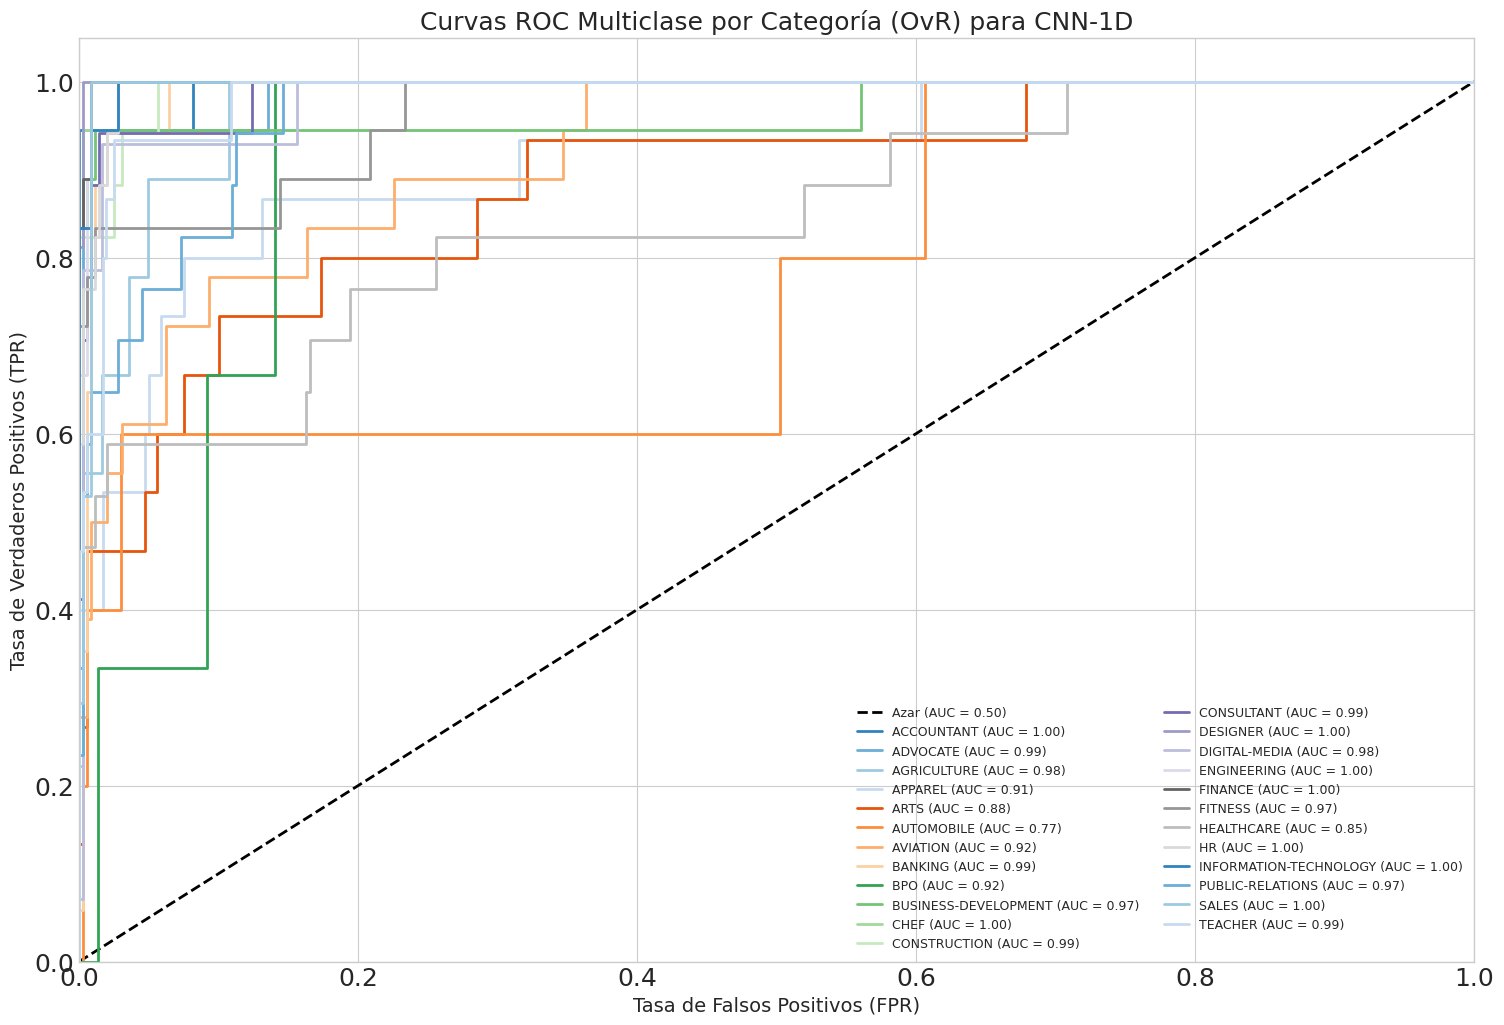

In [19]:
for i in range(num_clases):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized_cnn[:, i], y_pred_probs_cnn[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(18, 12)) 

colors = itertools.cycle(plt.cm.get_cmap('tab20c').colors)
plt.style.use('seaborn-v0_8-whitegrid') 

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.50)')

for i, color in zip(range(num_clases), colors):
    
    try:
        label_text = categorias[i]
    except (NameError, IndexError):
        label_text = f'Clase {i}'
        
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{label_text} (AUC = {roc_auc[i]:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('Curvas ROC Multiclase por Categoría (OvR) para CNN-1D', fontsize=18)

plt.legend(loc="lower right", fontsize=9, ncol=2) 
plt.grid(True)

plt.savefig('curva_roc_indvidual_cnn.png', bbox_inches='tight')
plt.show()

Además, la curva ROC AUC promedio de **0.96** muestra que el modelo tiene una excelente capacidad para distinguir entre las distintas clases. Al analizar las categorías de manera individual, se observa que incluso la clase con menor desempeño alcanza un AUC de **0.85**, mientras que la mayoría se aproxima a **1**, lo que indica que el modelo predice la gran mayoría de las categorías con un nivel muy alto de confiabilidad.

In [33]:
cnn_info = {
    
    'model_object': best_model_cnn,              
    'tokenizer': tokenizer_cnn,                  
    'embedding_matrix_shape': embedding_matrix_cnn.shape,                   

    'metrics_test': {
        'Accuracy': accuracy_cnn,
        'F1_Macro': f1_macro_cnn,
        'Recall_Macro': recall_macro_cnn,
        'Precision_Macro': precision_macro_cnn,
        'ROC_AUC_Macro': roc_auc_macro_cnn,
    },

    'best_params_used': best_params_cnn,         
    'best_val_f1_macro': best_val_f1_cnn,        

    'predictions_test': {
        'y_true_test': y_true_cnn.tolist(),
        'y_pred_test': y_pred_cnn.tolist(),
        'y_proba_test': y_pred_probs_cnn.tolist(),
    }
}

file_name = 'cnn_info.pkl'

try:
    with open(file_name, 'wb') as file:
        pickle.dump(cnn_info, file)
except Exception as e:
    print(f"Ocurrió un error al guardar el archivo: {e}")

### **Modelo 4: TF-IDF + XGBoost**

In [ ]:
num_clases_xgb = len(np.unique(y_train))

vectorizer_xgb = TfidfVectorizer( 
    max_features=30000, 
    ngram_range=(1, 3),
    min_df=1,
    max_df=0.8, 
    sublinear_tf=True
)

X_train_vect_xgb = vectorizer_xgb.fit_transform(X_train)
X_val_vect_xgb = vectorizer_xgb.transform(X_val)
X_test_vect_xgb = vectorizer_xgb.transform(X_test)

y_val_bin_xgb = to_categorical(y_val, num_classes=num_clases_xgb)

In [21]:
class MetricsCallback(TrainingCallback):
    def __init__(self, dval, y_val, y_val_bin):
        self.dval = dval
        self.y_val = y_val
        self.y_val_bin = y_val_bin
        self.history = []

    def after_iteration(self, model, epoch, evals_log):
        probs = model.predict(self.dval)
        preds = np.argmax(probs, axis=1)
        f1_macro = f1_score(self.y_val, preds, average='macro', zero_division=0)
        try:
            roc_auc = roc_auc_score(self.y_val_bin, probs, multi_class='ovr', average='macro')
        except ValueError:
            roc_auc = np.nan
        self.history.append({'Epoch': epoch, 'F1-Macro': f1_macro, 'ROC-AUC': roc_auc})
        return False

In [22]:
dtrain_xgb = xgb.DMatrix(X_train_vect_xgb, label=y_train)
dval_xgb   = xgb.DMatrix(X_val_vect_xgb, label=y_val)
dtest_xgb  = xgb.DMatrix(X_test_vect_xgb, label=y_test)

In [ ]:
base_params_xgb = {
    "tree_method": "hist",
    "device": "cuda",
    "predictor": "gpu_predictor",
    "objective": "multi:softprob",
    "num_class": num_clases_xgb,
    "eval_metric": "mlogloss",
    "random_state": 21
}

param_grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [6, 8, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'num_boost_round': [200, 400]
}

keys, values = zip(*param_grid_xgb.items())
all_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
random.seed(21)
MAX_TRIALS = 30
combinations_to_run = random.sample(all_combinations, min(MAX_TRIALS, len(all_combinations)))

In [ ]:
best_val_f1_xgb, best_model_xgb, best_params_xgb = 0, None, None
results_xgb = []

for params in combinations_to_run:
    num_rounds = params.pop('num_boost_round')
    current_params = base_params_xgb.copy()
    current_params.update(params)

    callback_metrics = MetricsCallback(dval_xgb, y_val, y_val_bin_xgb)
    model_xgb = xgb.train(
        current_params,
        dtrain_xgb,
        num_boost_round=num_rounds,
        evals=[(dval_xgb, 'validation')],
        callbacks=[callback_metrics],
        early_stopping_rounds=30,
        verbose_eval=False
    )

    history_df = pd.DataFrame(callback_metrics.history)
    if not history_df.empty:
        val_f1 = history_df['F1-Macro'].max()
        results_xgb.append({**params, 'num_boost_round': num_rounds, 'F1-Macro': val_f1})
        if val_f1 > best_val_f1_xgb:
            best_val_f1_xgb = val_f1
            best_model_xgb = model_xgb
            best_params_xgb = params.copy()
            best_model_xgb.save_model('best_tfidfxgb.json')
            best_params_xgb['best_iteration'] = model_xgb.best_iteration
    else:
        print("Entrenamiento fallido o sin registros de métricas.")

In [35]:
display(HTML("<h4>Mejores Hiperparámetros Encontrados:</h4>"))
params_df = pd.Series(best_params_xgb, name='Valor').to_frame()
params_df.index.name = 'Hiperparámetro'
display(params_df)

,Valor
Hiperparámetro,
learning_rate,0.05
max_depth,8.00
subsample,0.80
colsample_bytree,0.80
gamma,0.20
best_iteration,306.00


In [36]:
final_model_xgb = xgb.Booster()
final_model_xgb.load_model('best_tfidfxgb.json')

y_pred_probs_xgb = final_model_xgb.predict(dtest_xgb)
y_pred_xgb = np.argmax(y_pred_probs_xgb, axis=1)
y_true_xgb = y_test 

accuracy_xgb = accuracy_score(y_true_xgb, y_pred_xgb)
f1_macro_xgb = f1_score(y_true_xgb, y_pred_xgb, average='macro', zero_division=0)
recall_macro_xgb = recall_score(y_true_xgb, y_pred_xgb, average='macro', zero_division=0)
precision_macro_xgb = precision_score(y_true_xgb, y_pred_xgb, average='macro', zero_division=0)
roc_auc_macro_xgb = roc_auc_score(y_true_xgb, y_pred_probs_xgb, multi_class='ovr', average='macro')

results_xgb = {
    'Accuracy': accuracy_xgb,
    'Precision (Macro)': precision_macro_xgb,
    'F1-Score (Macro)': f1_macro_xgb,
    'Recall (Macro)': recall_macro_xgb,
    'ROC AUC (Macro)': roc_auc_macro_xgb
}

resultados['TF-IDF + XGBoost'] = results_xgb

df_results_xgb = pd.DataFrame.from_dict(resultados, orient='index')
df_results_xgb.index.name = 'Modelo'
display(df_results_xgb.loc[['TF-IDF + XGBoost']])

,Accuracy,Precision (Macro),F1-Score (Macro),Recall (Macro),ROC AUC (Macro)
Modelo,,,,,
TF-IDF + XGBoost,0.825737,0.79144,0.777748,0.78068,0.9822


El modelo TF-IDF + XGBoost demostró ser muy efectivo para la tarea de clasificación. Con una accuracy de **0.8257**, logró mantener un buen desempeño general en la mayoría de categorías. Su F1-Score macro de **0.7777** refleja un equilibrio consistente entre precisión y recall, mientras que el ROC AUC macro de **0.9822** indica que es altamente capaz de distinguir entre las diferentes clases, mostrando un nivel de confiabilidad superior en las predicciones. En conjunto, estos resultados sugieren que el modelo no solo acierta con frecuencia, sino que también maneja bien la discriminación entre categorías incluso en casos más desafiantes.

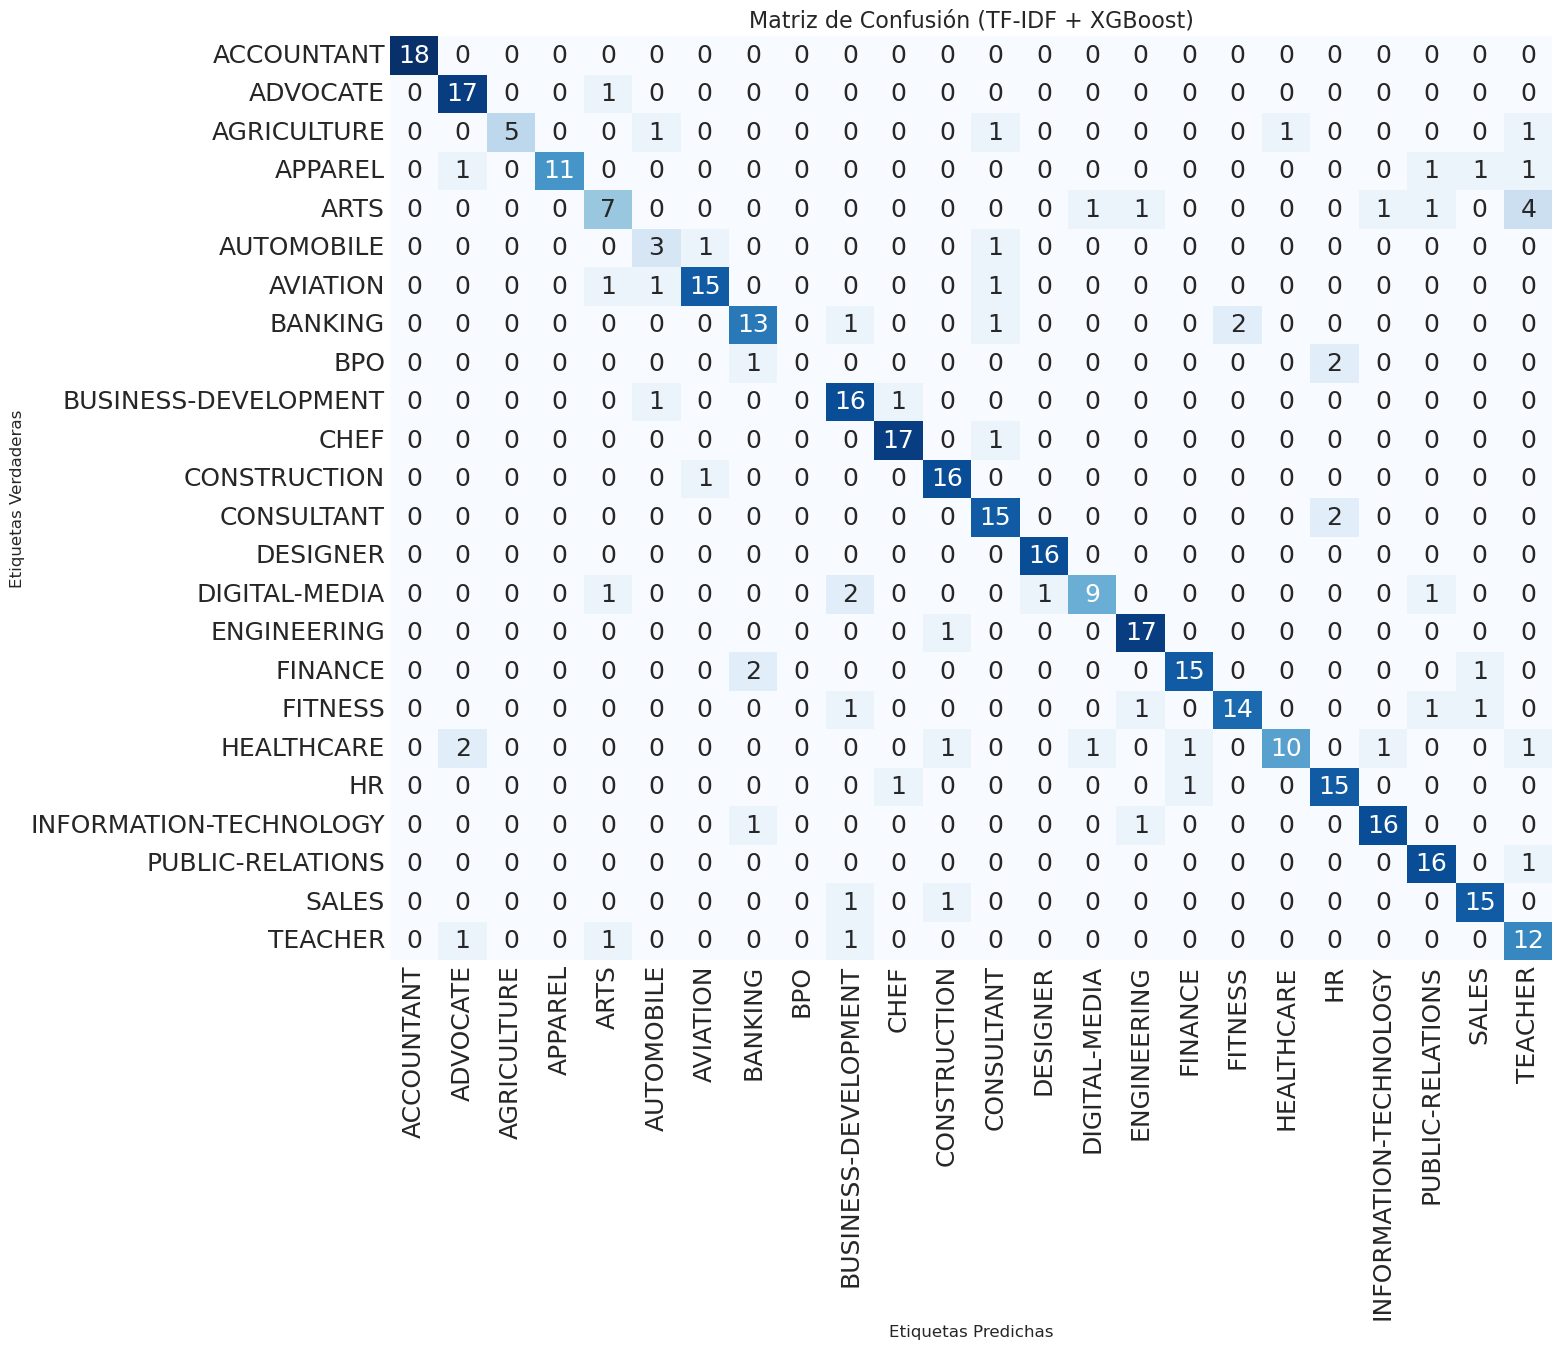

In [27]:
cm_xgb = confusion_matrix(y_true_xgb, y_pred_xgb)

plt.figure(figsize=(15, 12))
sns.heatmap(
    cm_xgb, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    cbar=False
)

try:
    plt.xticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=90)
    plt.yticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=0)
except NameError:
    pass

plt.xlabel("Etiquetas Predichas", fontsize=12)
plt.ylabel("Etiquetas Verdaderas", fontsize=12)
plt.title("Matriz de Confusión (TF-IDF + XGBoost)", fontsize=16)

plt.savefig('best_cm_conteo_xgb.png', bbox_inches='tight')

plt.show()

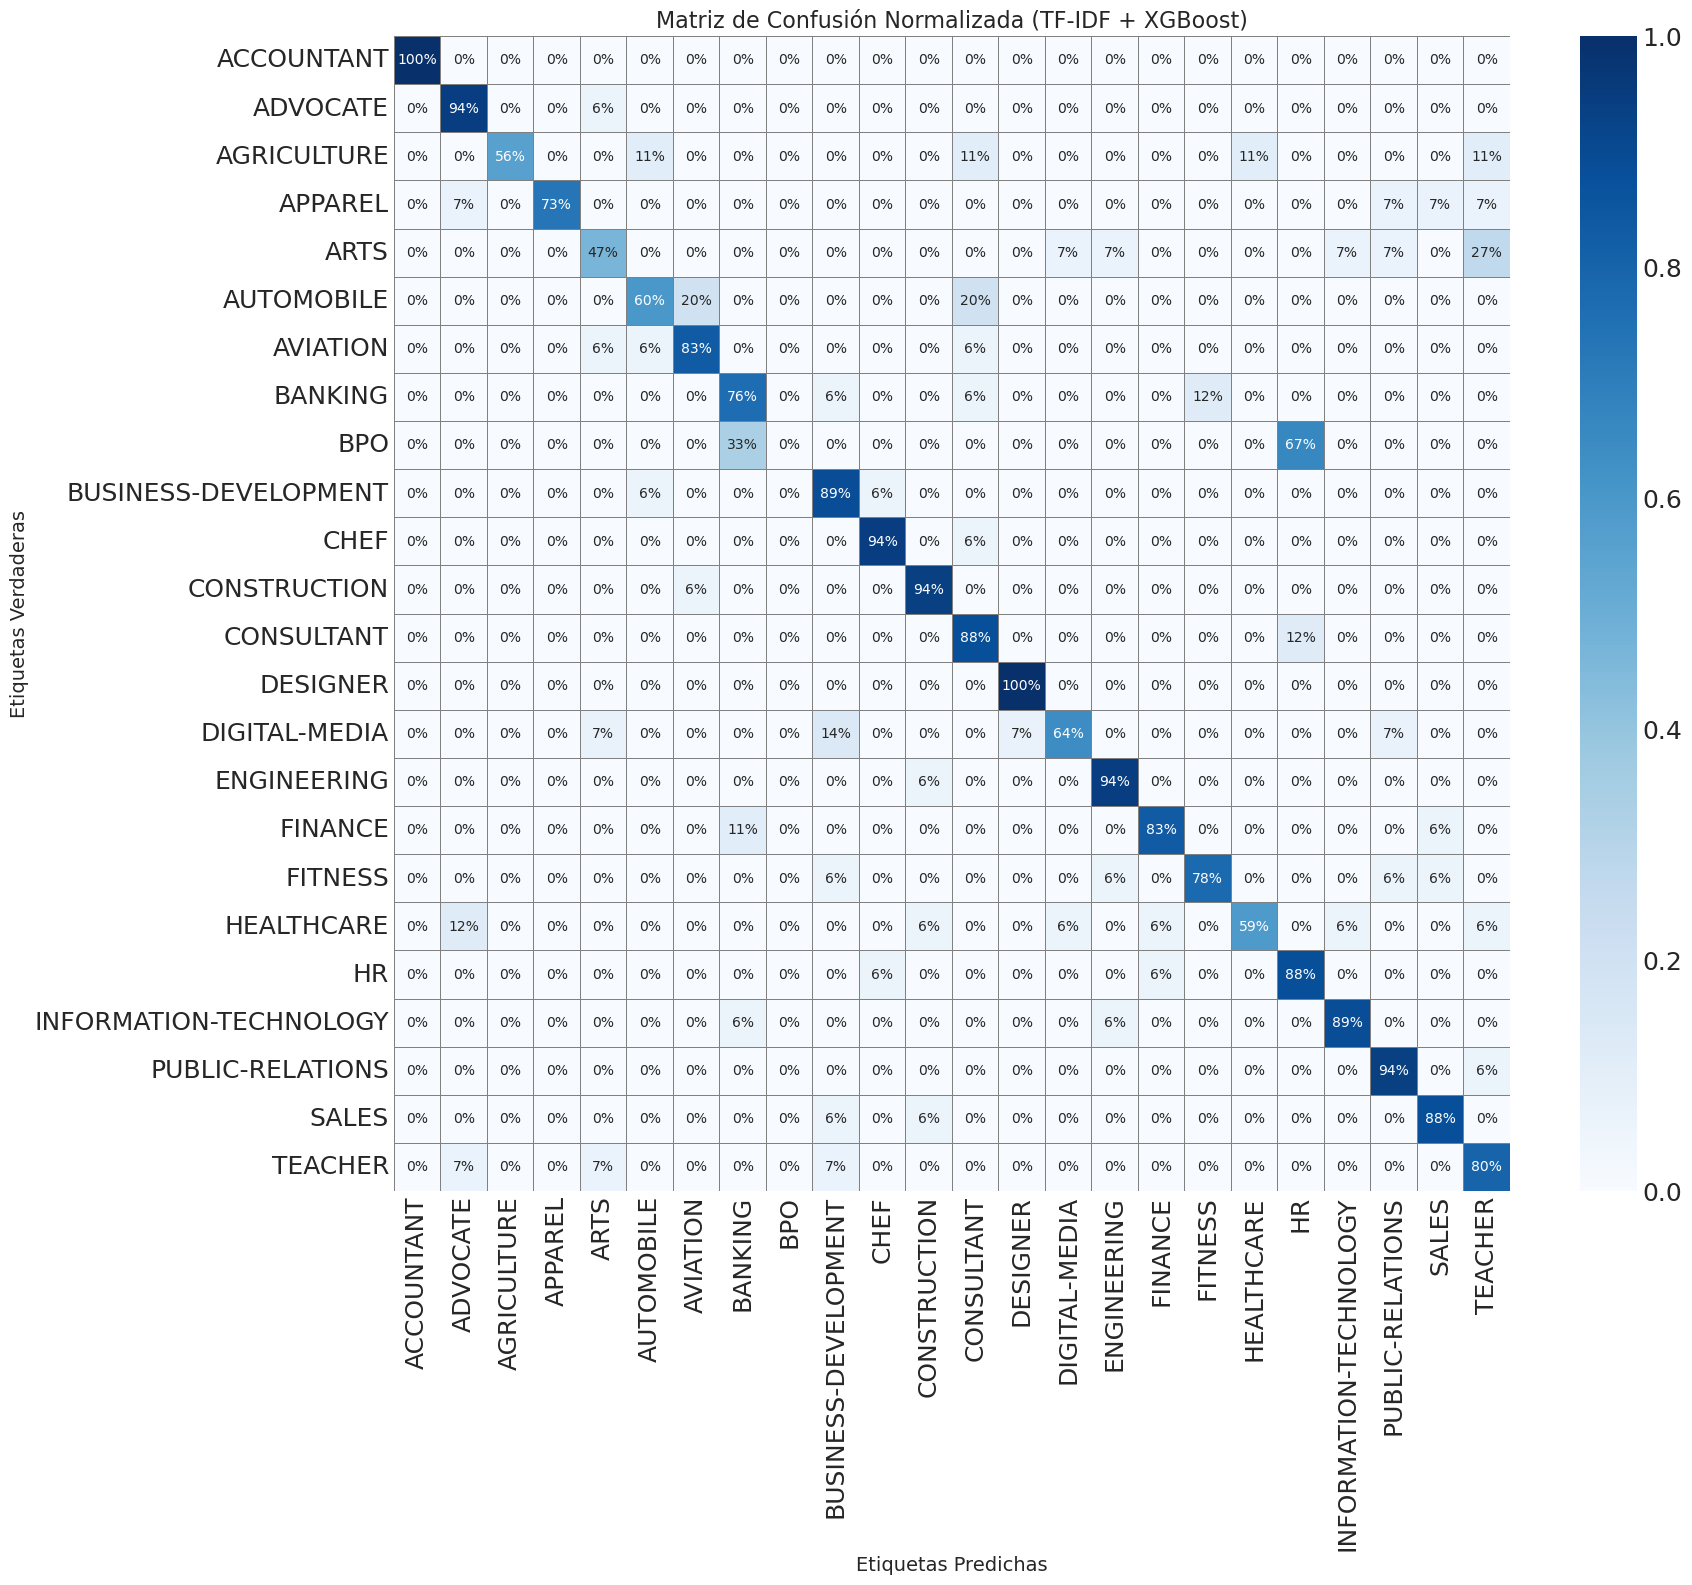

In [28]:
cm_normalized_xgb = cm_xgb.astype('float') / cm_xgb.sum(axis=1)[:, np.newaxis]
cm_normalized_xgb = np.nan_to_num(cm_normalized_xgb) 

plt.figure(figsize=(18, 15)) 

sns.heatmap(
    cm_normalized_xgb,           
    annot=True,              
    fmt='.0%',               
    cmap='Blues',            
    cbar=True,               
    linewidths=.5,           
    linecolor='gray',        
    annot_kws={"size": 10}  
)

try:
    plt.xticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=90)
    plt.yticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=0)
except NameError:
    pass

plt.xlabel("Etiquetas Predichas", fontsize=14)
plt.ylabel("Etiquetas Verdaderas", fontsize=14)
plt.title("Matriz de Confusión Normalizada (TF-IDF + XGBoost)", fontsize=16)

plt.savefig('cm_normalizada_xgb.png', bbox_inches='tight') 

plt.show()

Observando la matriz de confusión, se evidencia que el modelo mostró un desempeño sólido en términos generales. De las **24** categorías, **20** superaron el **60%** de aciertos, con **2** alcanzando **100%** y **5** llegando a **94%**, mientras que varias otras superaron el **80%**. No obstante, algunas clases presentan valores bajos en la diagonal, incluyendo la categoría BPO, que registró **0** aciertos, lo que indica que el modelo aún enfrenta dificultades significativas para clasificar ciertas clases.

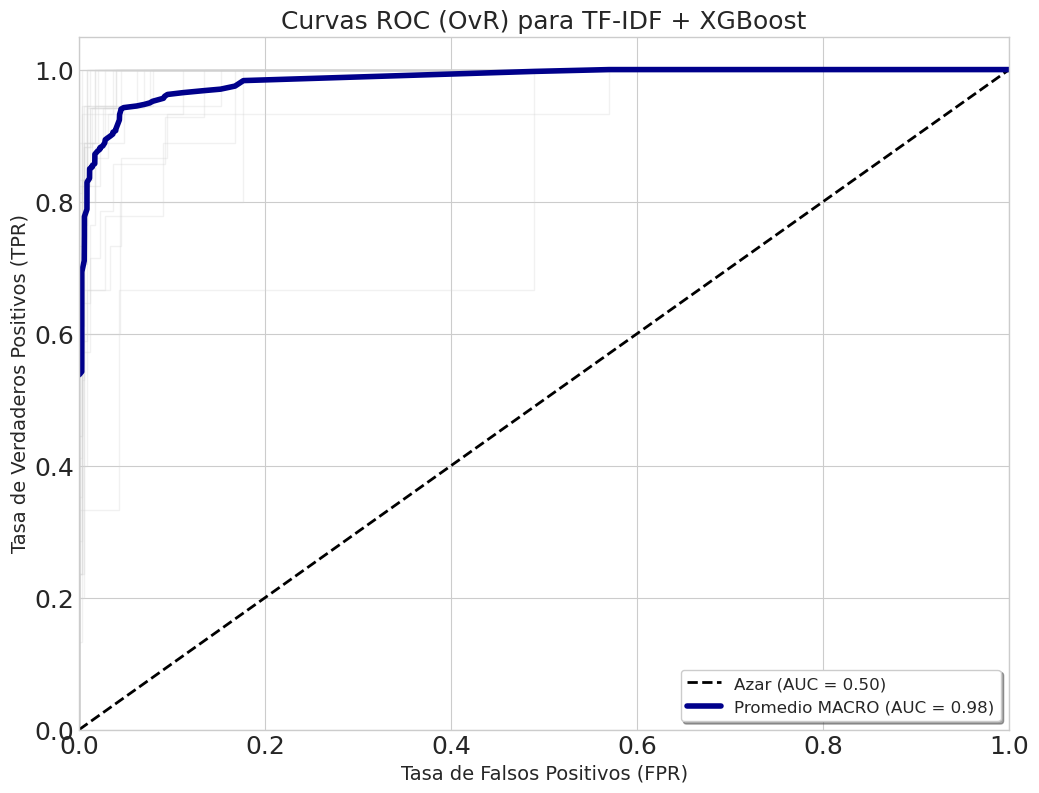

In [29]:
y_true_binarized_xgb = label_binarize(y_true_xgb, classes=np.arange(num_clases_xgb))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_clases_xgb):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized_xgb[:, i], y_pred_probs_xgb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_clases_xgb)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_clases_xgb):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_clases_xgb 
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.style.use('seaborn-v0_8-whitegrid') 
plt.figure(figsize=(12, 9))

for i in range(num_clases_xgb):
    plt.plot(fpr[i], tpr[i], 
             color='lightgray', 
             alpha=0.3,       
             lw=1)            

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.50)')

plt.plot(
    fpr["macro"],
    tpr["macro"],
    label=f'Promedio MACRO (AUC = {roc_auc["macro"]:.2f})', 
    color='darkblue',    
    linestyle='-',       
    linewidth=4          
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('Curvas ROC (OvR) para TF-IDF + XGBoost', fontsize=18)

plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(True)

plt.savefig('curva_roc_general_xgb.png', bbox_inches='tight')

plt.show()

/tmp/ipykernel_544/2800992008.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = itertools.cycle(plt.cm.get_cmap('tab20c').colors)


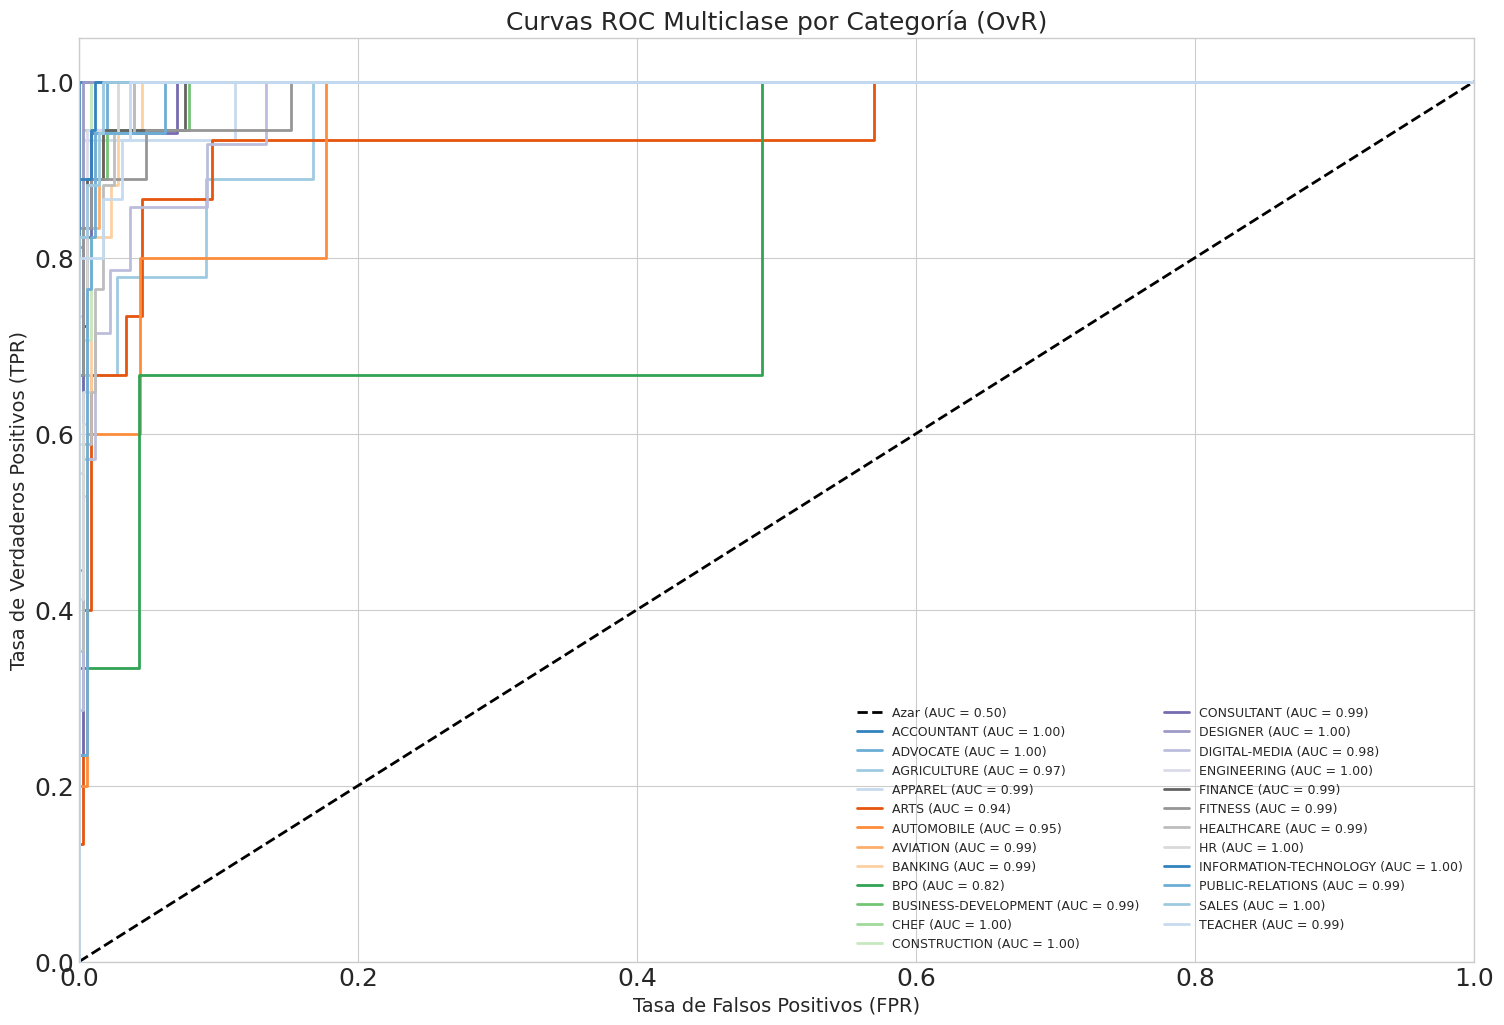

In [30]:
for i in range(num_clases_xgb):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized_xgb[:, i], y_pred_probs_xgb[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(18, 12)) 

colors = itertools.cycle(plt.cm.get_cmap('tab20c').colors)
plt.style.use('seaborn-v0_8-whitegrid') 

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.50)')

for i, color in zip(range(num_clases_xgb), colors):
    
    try:
        label_text = categorias[i]
    except (NameError, IndexError):
        label_text = f'Clase {i}'
        
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{label_text} (AUC = {roc_auc[i]:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('Curvas ROC Multiclase por Categoría (OvR)', fontsize=18)

plt.legend(loc="lower right", fontsize=9, ncol=2) 
plt.grid(True)

plt.savefig('curva_roc_indvidual_xgb.png', bbox_inches='tight')
plt.show()

La curva ROC AUC promedio de **0.98** indica que el modelo tiene una capacidad sobresaliente para distinguir entre las distintas clases. Analizando cada categoría individualmente, la mayoría alcanzó valores de AUC muy altos, entre **0.94 y 1**, lo que refleja una gran confianza en las predicciones. Por su parte, BPO obtuvo un valor más bajo, **0.82**, mostrando que sigue siendo algo complejo para el modelo.

In [31]:
xgb_info = {
    
    'model_object': best_model_xgb,         
    'vectorizer': vectorizer_xgb,           
    'class_names': categorias,
    
    # Métricas Finales (Con el enfoque Macro)
    'metrics_test': {
        'Accuracy': accuracy_xgb,
        'F1_Macro': f1_macro_xgb,
        'Recall_Macro': recall_macro_xgb,
        'Precision_Macro': precision_macro_xgb,
        'ROC_AUC_Macro': roc_auc_macro_xgb,
    },
    
    # Parámetros y Historial
    'best_params_used': best_params_xgb, 
    'training_history_last_run': callback_metrics.history,
    
    'predictions_test': {
        'y_pred_test': y_pred_xgb.tolist(),
        'y_proba_test': y_pred_probs_xgb.tolist(),
        'y_true_test': y_true_xgb.tolist(),
    },
    
}

file_name = 'xgb_info.pkl' 

try:
    with open(file_name, 'wb') as file:
        pickle.dump(xgb_info, file)
    
except Exception as e:
    print(f"Ocurrió un error al guardar el archivo: {e}")

### **FastText**

In [10]:
DATA_DIR = "../data"
EMB_PATH = "../docs/cc.en.300.vec"   
BASE_DIR = "../fasttext_run"
os.makedirs(BASE_DIR, exist_ok=True)

train_txt_fasttext = os.path.join(BASE_DIR, "fasttext_train.txt")
val_txt_fasttext   = os.path.join(BASE_DIR, "fasttext_val.txt")
test_txt_fasttext  = os.path.join(BASE_DIR, "fasttext_test.txt")
model_bin_fasttext = os.path.join(BASE_DIR, "fasttext_model.bin")

fasttext_text_col  = "Resume"
fasttext_label_col = "Category"

In [11]:
def fasttext_export_txt(df, text_col, label_col, filepath):
    with open(filepath, "w", encoding="utf-8") as f:
        for text, label in zip(df[text_col], df[label_col]):
            text = str(text).replace("\n", " ").replace("\t", " ").strip()
            if text:
                f.write(f"__label__{label} {text}\n")

fasttext_export_txt(train_df, fasttext_text_col, fasttext_label_col, train_txt_fasttext)
fasttext_export_txt(val_df,   fasttext_text_col, fasttext_label_col, val_txt_fasttext)
fasttext_export_txt(test_df,  fasttext_text_col, fasttext_label_col, test_txt_fasttext)

In [12]:
start_time = time.time()
try:
    fasttext_model = fasttext.train_supervised(
        input=train_txt_fasttext,
        pretrainedVectors=EMB_PATH,
        dim=300,
        epoch=25,
        lr=0.5,
        wordNgrams=2,
        loss='softmax',
        minCount=1,
        bucket=2000000,
        minn=0,
        maxn=0,
        thread=8,
        verbose=2
    )

    training_time = time.time() - start_time
    print(f"\nEntrenamiento completado en {training_time:.1f} s.")
    fasttext_model.save_model(model_bin_fasttext)

except Exception as e:
    print("Error durante entrenamiento FastText")
    traceback.print_exc()

Read 1M words
Number of words:  31589
Number of labels: 24
Progress: 100.0% words/sec/thread:  400977 lr:  0.000000 avg.loss:  0.434879 ETA:   0h 0m 0s 21.3% words/sec/thread:  355769 lr:  0.393581 avg.loss:  1.636965 ETA:   0h 0m21s



Entrenamiento completado en 186.2 s.


In [13]:
fasttext_texts_test = test_df[fasttext_text_col].astype(str).tolist()
fasttext_labels_true = test_df[fasttext_label_col].astype(str).tolist()

# Obtener todas las etiquetas posibles del modelo
labels_all = fasttext_model.get_labels()
labels_all = [lbl.replace("__label__", "") for lbl in labels_all]

# Predecir probabilidades
fasttext_preds = [fasttext_model.predict(t, k=len(labels_all)) for t in fasttext_texts_test]

# Extraer las probabilidades y etiquetas
probs = [dict(zip([lbl.replace("__label__", "") for lbl in p[0]], p[1])) for p in fasttext_preds]

# Convertir a matriz de probabilidades (una columna por etiqueta)
probs_matrix = np.array([[p.get(lbl, 0.0) for lbl in labels_all] for p in probs])

# Convertir las etiquetas verdaderas a formato binario (one-vs-rest)
from sklearn.preprocessing import label_binarize
y_true_bin = label_binarize(fasttext_labels_true, classes=labels_all)

# Calcular métricas
fasttext_labels_pred = [max(p, key=p.get) for p in probs]  # predicción más probable

accuracy_macro_fasttext  = accuracy_score(fasttext_labels_true, fasttext_labels_pred)
precision_macro_fasttext = precision_score(fasttext_labels_true, fasttext_labels_pred, average='macro', zero_division=0)
recall_macro_fasttext    = recall_score(fasttext_labels_true, fasttext_labels_pred, average='macro', zero_division=0)
f1_macro_fasttext        = f1_score(fasttext_labels_true, fasttext_labels_pred, average='macro', zero_division=0)

# AUC macro
roc_auc_macro_fasttext = roc_auc_score(y_true_bin, probs_matrix, average='macro', multi_class='ovr')

# Guardar resultados
fasttext_results = {
    'Accuracy': accuracy_macro_fasttext,
    'Precision (Macro)': precision_macro_fasttext,
    'Recall (Macro)': recall_macro_fasttext,
    'F1-Score (Macro)': f1_macro_fasttext,
    'ROC AUC (Macro)': roc_auc_macro_fasttext
}

resultados['FastText'] = fasttext_results

df_results_fasttext = pd.DataFrame.from_dict(resultados, orient='index')
df_results_fasttext.index.name = 'Modelo'

display(pd.DataFrame([fasttext_results], index=['FastText']))


,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),ROC AUC (Macro)
FastText,0.672922,0.646081,0.63239,0.63148,0.953611


El modelo FastText tuvo un desempeño aceptable en la prueba, con una accuracy de **0.6729**. Su F1-Score macro de **0.6314** indica que, aunque logra un equilibrio entre precisión y recall, todavía presenta dificultades para clasificar correctamente algunas categorías. Aun así, su ROC AUC macro de **0.9536** muestra que, en general, el modelo puede diferenciar bien entre las clases.

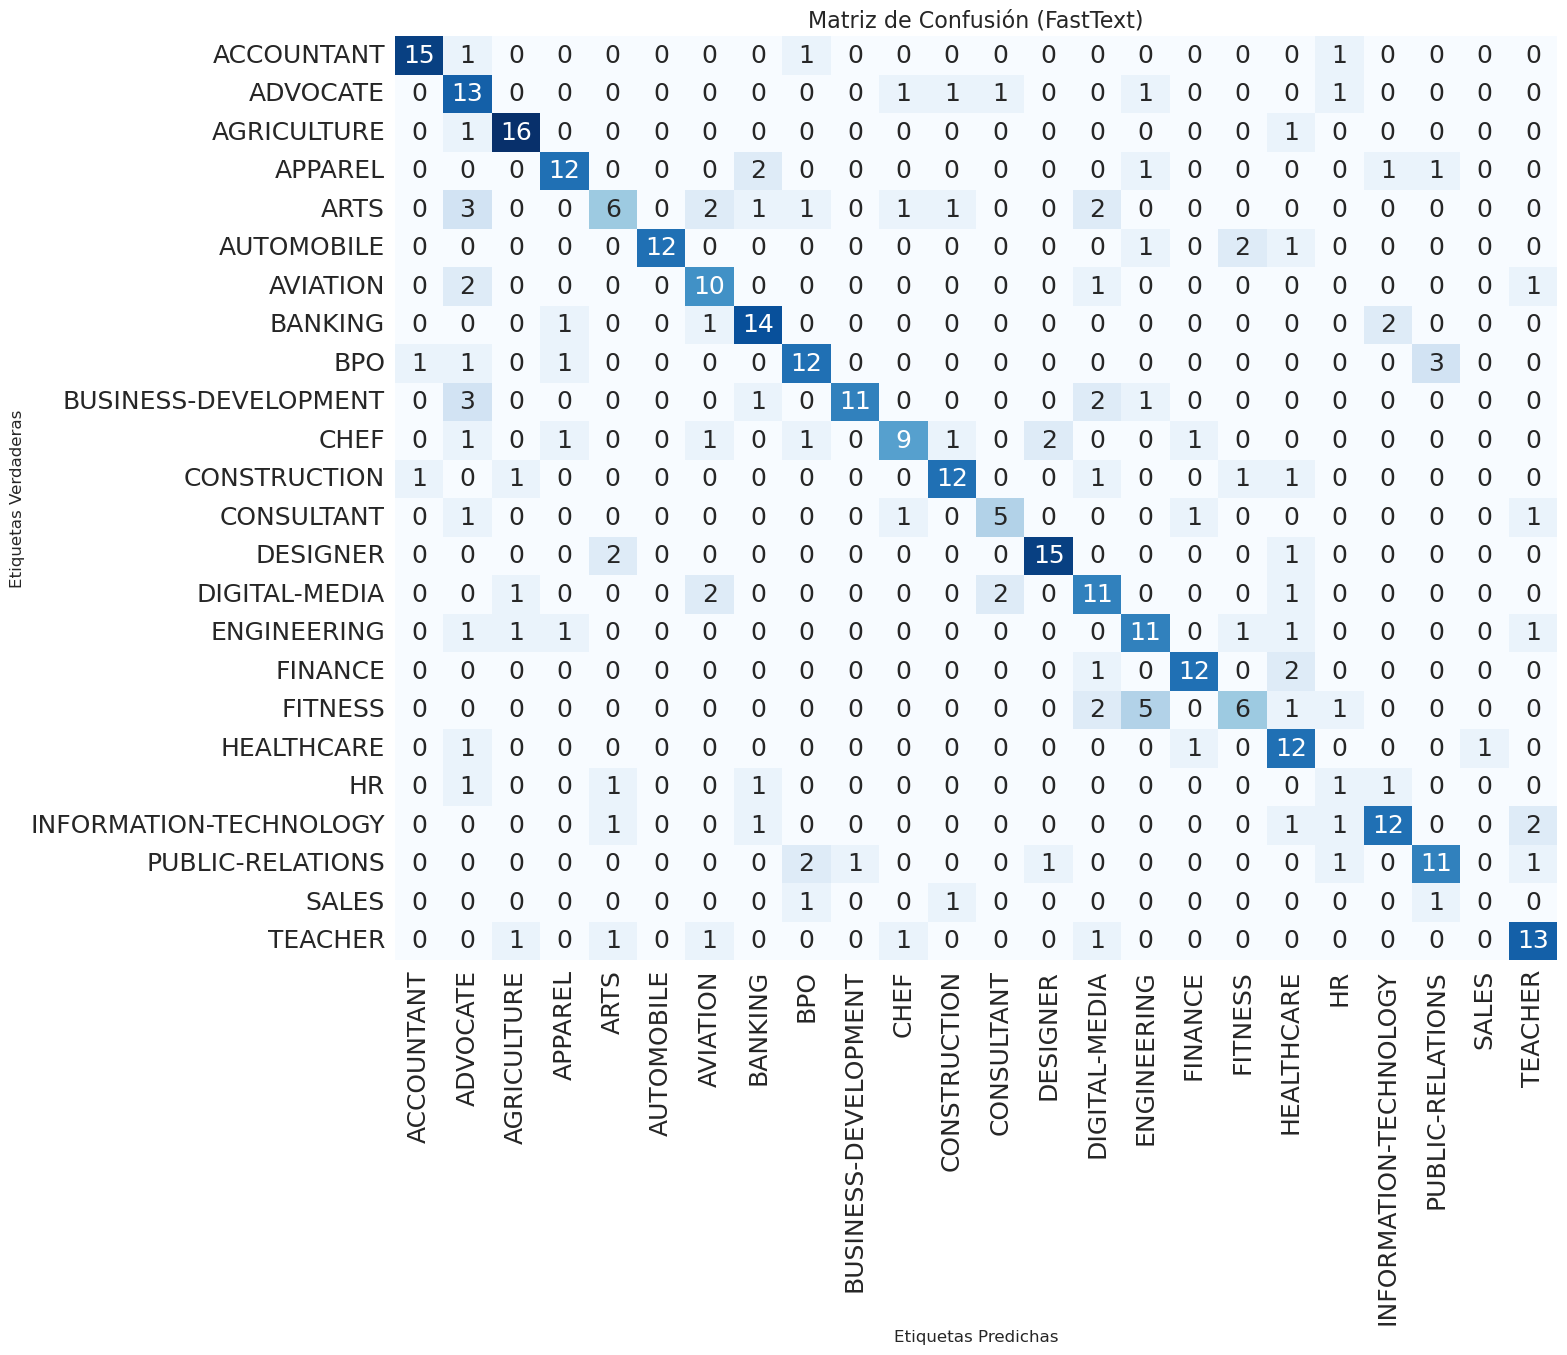

In [15]:
cm_fasttext = confusion_matrix(fasttext_labels_true, fasttext_labels_pred)
plt.figure(figsize=(15, 12))
sns.heatmap(
    cm_fasttext,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

try:
    plt.xticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=90)
    plt.yticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=0)
except NameError:
    pass

plt.xlabel("Etiquetas Predichas", fontsize=12)
plt.ylabel("Etiquetas Verdaderas", fontsize=12)
plt.title("Matriz de Confusión (FastText)", fontsize=16)

plt.savefig(os.path.join(BASE_DIR, "cm_fasttext_conteo.png"), bbox_inches='tight')
plt.show()

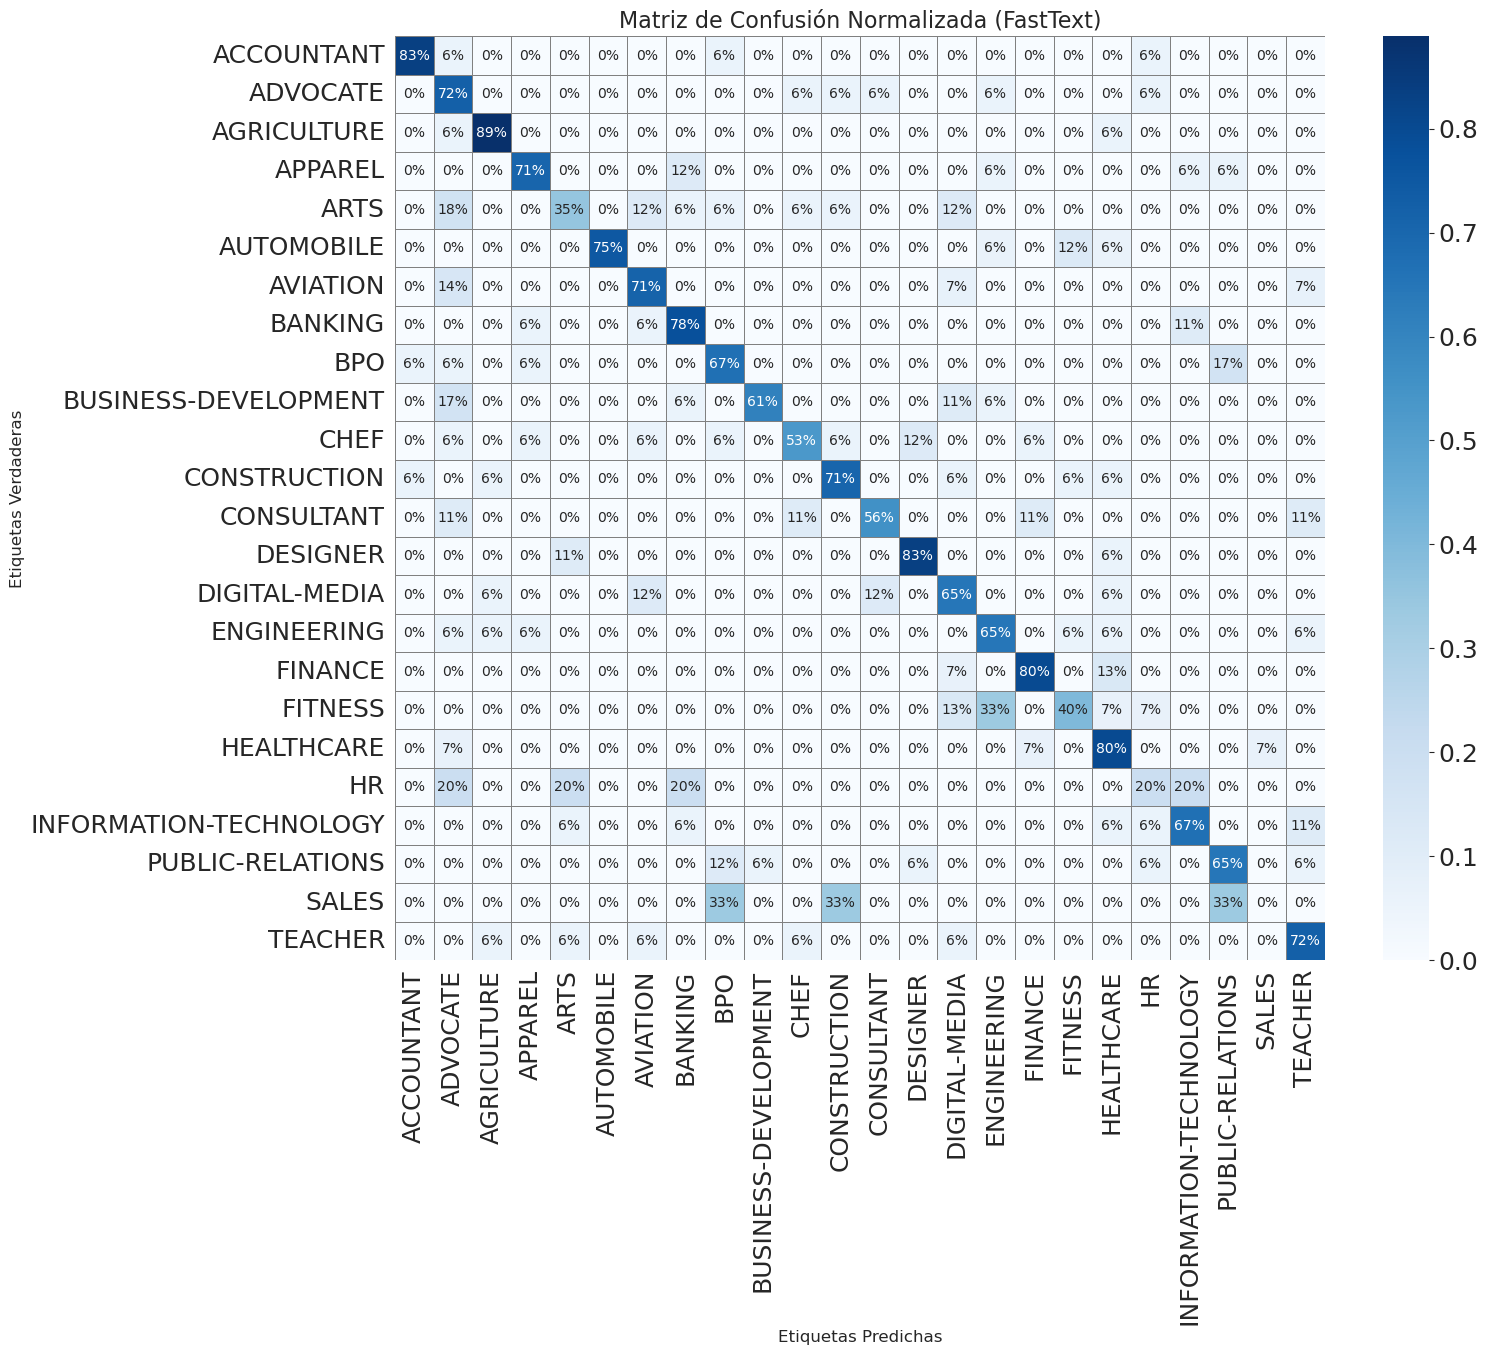

In [16]:
cm_normalizada_fasttext = cm_fasttext.astype('float') / cm_fasttext.sum(axis=1)[:, np.newaxis]
cm_normalizada_fasttext = np.nan_to_num(cm_normalizada_fasttext)  

plt.figure(figsize=(15, 12))
sns.heatmap(
    cm_normalizada_fasttext,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    cbar=True,
    linewidths=.5,
    linecolor='gray',
    annot_kws={"size":10}
)

try:
    plt.xticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=90)
    plt.yticks(ticks=np.arange(len(categorias)) + 0.5, 
               labels=categorias, rotation=0)
except NameError:
    pass

plt.xlabel("Etiquetas Predichas", fontsize=12)
plt.ylabel("Etiquetas Verdaderas", fontsize=12)
plt.title("Matriz de Confusión Normalizada (FastText)", fontsize=16)

plt.savefig(os.path.join(BASE_DIR, "cm_fasttext_normalizada.png"), bbox_inches='tight')
plt.show()

A partir de las matrices de confusión del modelo FastText, se nota que tuvo un rendimiento desigual. De las 24 categorías, **18** superaron el **60%** de aciertos, y **5** lograron más del **80%**. La categoría Sales no tuvo aciertos (**0%**). También se observan algunas categorías con valores bajos, alrededor del **20%**, lo que muestra que el modelo tuvo problemas para predecir correctamente ciertas clases. 

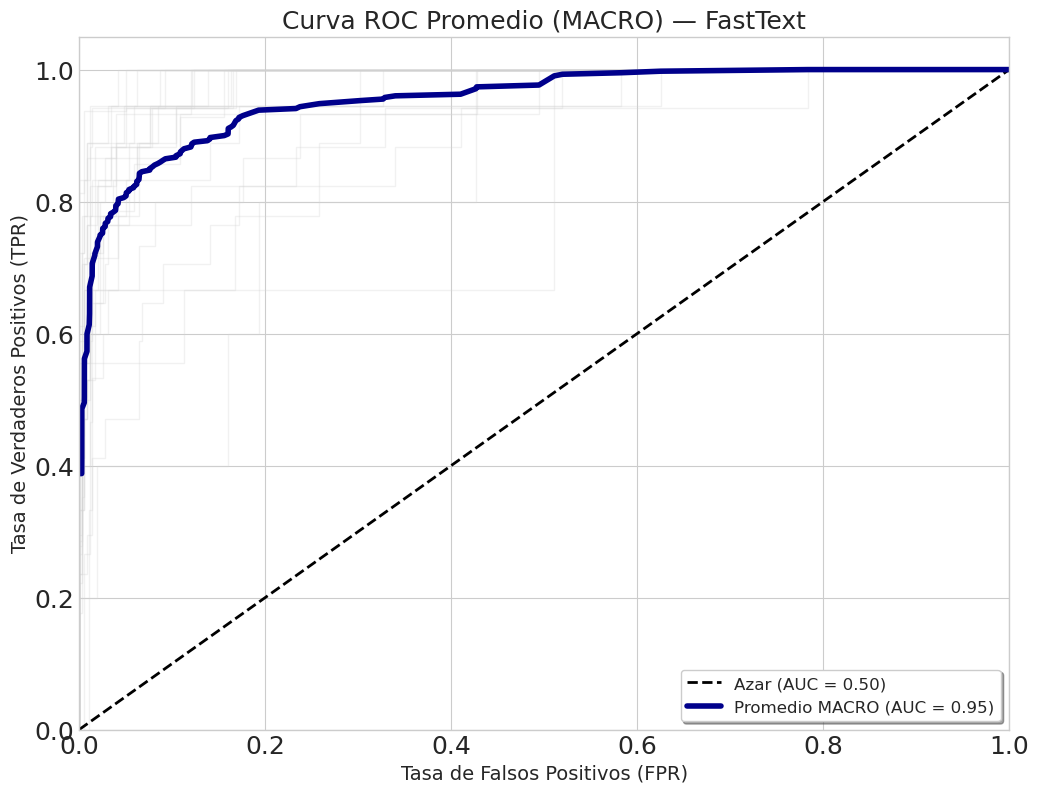

In [17]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_clases):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs_matrix[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_clases)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_clases):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_clases

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 9))

# Curvas individuales en gris
for i in range(num_clases):
    plt.plot(fpr[i], tpr[i], color='lightgray', alpha=0.3, lw=1)

# Línea de azar
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.50)')

# Curva promedio
plt.plot(
    fpr["macro"], tpr["macro"],
    label=f'Promedio MACRO (AUC = {roc_auc["macro"]:.2f})',
    color='darkblue', linestyle='-', linewidth=4
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('Curva ROC Promedio (MACRO) — FastText', fontsize=18)
plt.legend(loc="lower right", fontsize=12, frameon=True, shadow=True)
plt.grid(True)
plt.savefig('curva_roc_general_fasttext.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_627/3329604492.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = itertools.cycle(plt.cm.get_cmap('tab20c').colors)


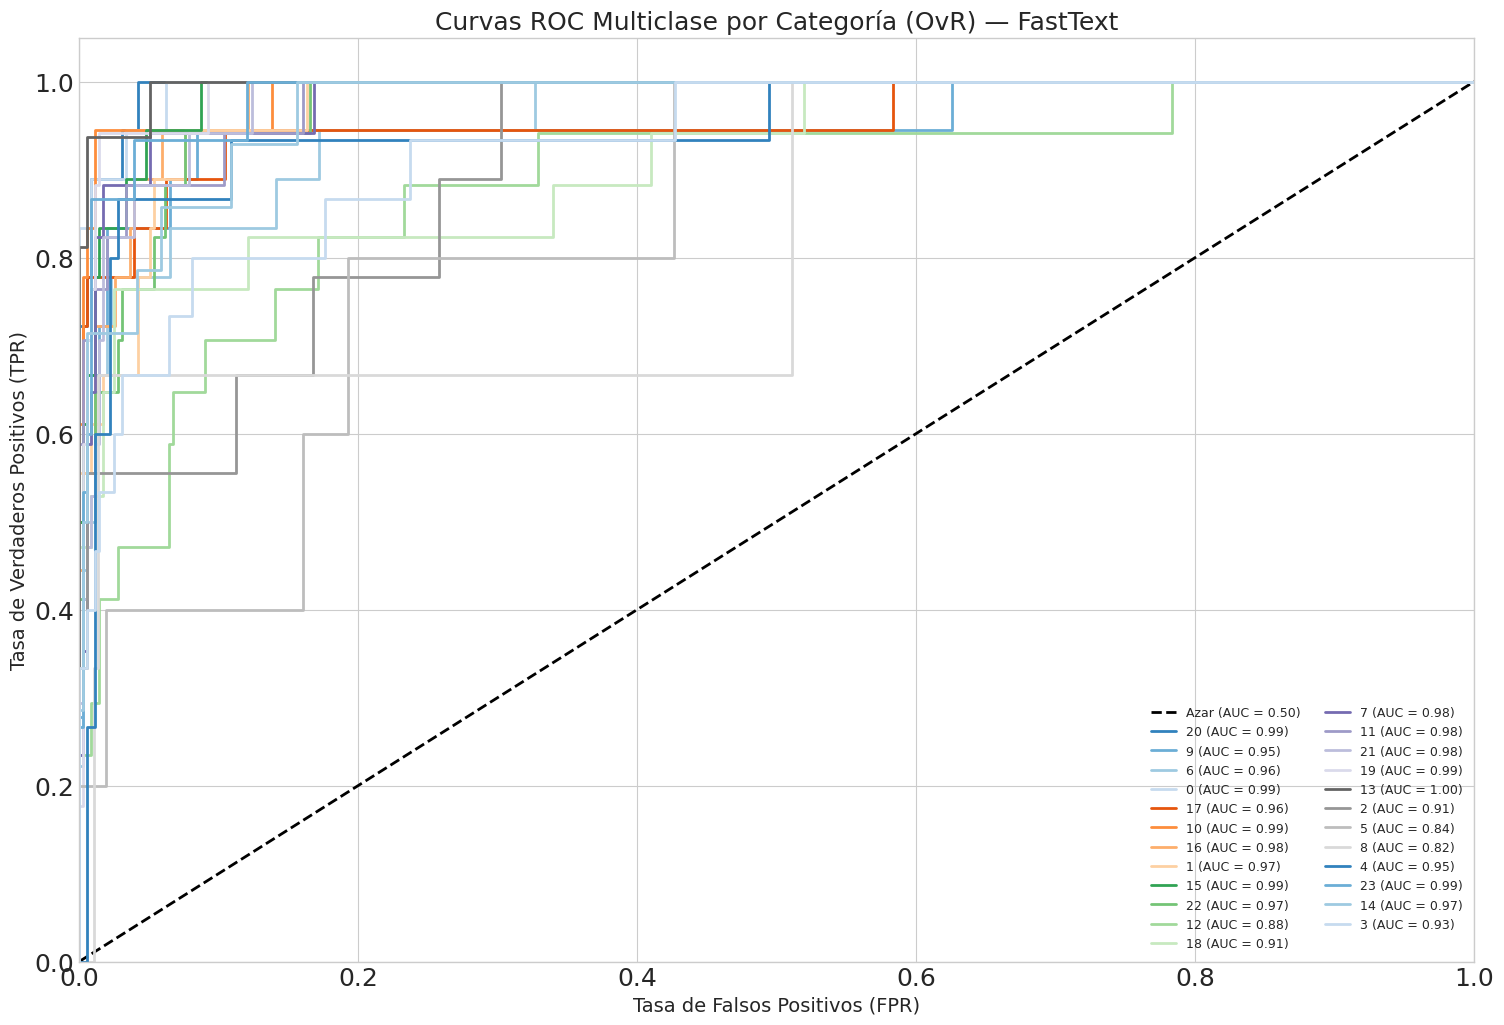

In [18]:
plt.figure(figsize=(18, 12))
plt.style.use('seaborn-v0_8-whitegrid')

# Línea de azar
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.50)')

colors = itertools.cycle(plt.cm.get_cmap('tab20c').colors)

for i, color in zip(range(num_clases), colors):
    label_text = labels_all[i] if i < len(labels_all) else f'Clase {i}'
    if len(label_text) > 25:  # si el nombre es muy largo, se trunca
        label_text = label_text[:25] + "..."
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{label_text} (AUC = {roc_auc[i]:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('Curvas ROC Multiclase por Categoría (OvR) — FastText', fontsize=18)
plt.legend(loc="lower right", fontsize=9, ncol=2)
plt.grid(True)
plt.savefig('curva_roc_individual_fasttext.png', bbox_inches='tight')
plt.show()

La curva ROC AUC promedio de **0.95** muestra que el modelo tiene buena capacidad para diferenciar entre las distintas clases. Analizando cada categoría de manera individual, la mayoría logró valores de AUC superiores a **0.9**, mientras que el rango completo va de **0.82 a 1**, lo que indica que, aunque la mayoría de las predicciones son bastante confiables.

In [19]:
fasttext_info = {
    "model_path": model_bin_fasttext,          
    "metrics_test": {
        "Accuracy": accuracy_macro_fasttext,
        "Precision (Macro)": precision_macro_fasttext,
        "Recall (Macro)": recall_macro_fasttext,
        "F1-Score (Macro)": f1_macro_fasttext,
        "ROC AUC (Macro)": roc_auc_macro_fasttext
    },
    "labels": {
        "y_true": fasttext_labels_true,
        "y_pred": fasttext_labels_pred
    }
}

summary_path = os.path.join(BASE_DIR, "fasttext_summary.pkl")
with open(summary_path, "wb") as f:
    pickle.dump(fasttext_info, f)